<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>Hypothesis 2 검정: 고성능 GPU일수록 BTC 가격 변동에 더 민감한가</mark></b></span><br><br>

<b>[가설]</b><br>
• Hypo 2: <b>고성능 그래픽카드일수록 비트코인 가격 변동에 더 심하게 반응한다.</b><br>
• 여기서 핵심은 high 그룹의 평균 수익률이 단순히 더 높은지가 아니라, <b>BTC 수익률이 움직일 때 high 그룹의 반응계수가 low 그룹보다 더 큰가</b>이다.<br>
• 따라서 최종 검정은 단순 평균 비교가 아니라 <b>BTC 수익률 × 성능군 상호작용 회귀</b>로 수행한다.<br><br>

<b>[성능군 분류 기준: 본분석]</b><br>
• 본분석은 EDA_process에서 이미 생성한 <b>chip_perf_group = low / mid / high</b>를 그대로 사용한다.<br>
• <b>high</b>: RTX/RX 80급 이상, RTX/RX 70급 중 Ti/SUPER/XT/XTX/GRE 등 상위 파생형을 포함한 고성능 칩셋<br>
• <b>mid</b>: RTX/RX 60급, RTX/RX 70급 일반형, GTX 1660 이상, ARC A770/A750/A580 등 중간 성능 칩셋<br>
• <b>low</b>: GT 계열, GTX 1660 미만, RX 60급 미만, 하위 ARC 등 보급형 칩셋<br>
• workstation, mobile/laptop, unknown 계열은 H2 본분석에서 제외되어 있다.<br><br>

<b>[VRAM proxy 기준: 보조분석]</b><br>
• VRAM 기준 분류는 <b>h2_perf_group</b>으로 저장된 보조 성능 proxy이다.<br>
• <b>high</b>: VRAM ≥ 12GB<br>
• <b>mid</b>: 6GB &lt; VRAM &lt; 12GB<br>
• <b>low</b>: VRAM ≤ 6GB<br>
• 단, VRAM은 성능 그 자체가 아니다. 예를 들어 VRAM이 큰 mid급 칩셋이나, VRAM은 작아도 연산 성능이 높은 칩셋이 존재할 수 있다. 따라서 <b>최종 결론은 chip_perf_group 기준</b>을 중심으로 해석하고, VRAM 기준은 발표 슬라이드의 8GB/16GB/24GB 직관을 보조하는 강건성 분석으로만 사용한다.<br><br>

<b>[통제 변수와 허용한 외생 요인]</b><br>
• <b>fx_ret</b>: GPU 가격이 원화 기준이므로 USD/KRW 환율 효과를 통제한다.<br>
• <b>nvda_ret</b>: AI/반도체 수요 proxy로 사용한다. 특히 high GPU 가격 상승이 BTC 때문이 아니라 AI 수요 때문이라는 반론을 줄이기 위한 통제이다.<br>
• <b>NVDA × 성능군</b>: AI 수요가 고성능 GPU에 더 강하게 작용할 수 있으므로 성능군별 AI 민감도 차이도 통제한다.<br>
• <b>gpu_ret_l1</b>: GPU 가격 수익률 자체의 단기 관성을 통제한다.<br><br>

<b>[한계와 추가 보완]</b><br>
• 금리, 글로벌 유동성, NASDAQ/SOX, 국내 소비 시즌성, 재고/품절, 프로모션, 정확한 신제품 출시일 더미는 본 데이터셋에 직접 들어 있지 않다.<br>
• 특히 <b>신제품 출시 효과</b>는 high GPU 가격에 불연속적인 충격을 만들 수 있으므로 중요한 한계이다. 정확한 출시일 테이블이 없으면 임의 더미를 넣는 것이 오히려 자의적일 수 있어, 본 노트북에서는 수동 출시일 더미를 본모형에 강제로 넣지 않는다.<br>
• 대신 이미 생성된 <b>panel_gpu.csv</b>와 <b>gap_week.csv</b>를 이용해 성능군별 제품 진입/표본구성 변화 proxy를 만들고, 이를 통제하는 <b>composition-control robustness</b>를 추가한다.<br>
• BTC lag 0~8주를 모두 넣으면 자유도와 다중공선성 문제가 생길 수 있으므로, 개별 lag p-value가 아니라 <b>공동 유의성 검정</b>과 <b>누적 효과</b>를 핵심 판단 기준으로 삼고, 별도로 lag-window 축약 모형을 강건성 분석으로 확인한다.<br><br>

<b>[사용 데이터]</b><br>
• <b>ret_chip_w.csv</b>: 칩셋 성능군별 주간 로그수익률, H2 본분석<br>
• <b>idx_chip_w.csv</b>: 칩셋 성능군별 가격지수, 시각화용<br>
• <b>ret_vram_w.csv</b>, <b>idx_vram_w.csv</b>: VRAM proxy 강건성 분석<br>
• <b>panel_gpu.csv</b>: 제품 단위 패널 강건성 분석 및 제품구성 변화 proxy 생성<br>
• <b>gap_week.csv</b>: 성능군별 adjacent match 수와 bridge gap 수를 이용한 지수 안정성/구성 변화 proxy<br>
• <b>outputs/hypo1/h1_regression_dataset.csv</b>: Hypo 1에서 이미 만든 BTC, FX, NVDA 주간 시장변수<br>
</div>

In [1]:
# Hypothesis 2 setup

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# 기존 전처리 output과 Hypo 1 output을 그대로 사용한다.
OUT = Path("outputs")
H1_DIR = OUT / "hypo1"
H2_DIR = OUT / "hypo2"
H2_DIR.mkdir(parents=True, exist_ok=True)

L = 8
GROUPS = ["high", "mid", "low"]
BASE = "low"

# Hypo 1에서 생성된 동일한 시장변수를 재사용해 H1/H2의 시장자료 기준을 일치시킨다.
MKT_FILE = H1_DIR / "h1_regression_dataset.csv"

plt.rcParams["font.family"] = 'MalGun Gothic'
plt.rcParams["axes.unicode_minus"] = False

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>0. 기존 output 로드 및 성능군 표본 확인</mark></b></span><br><br>

<b>[왜 이 과정이 필요한가]</b><br>
Hypo 2는 EDA_process에서 이미 산출한 성능군별 Chain Matched Jevons Index와 검정용 주간 로그수익률을 사용한다. 따라서 여기서는 제품명 파싱, 0값 처리, 주간 대표가격 산출, chain matching을 다시 수행하지 않는다.<br><br>

<b>[확인할 내용]</b><br>
• chip 기준 high/mid/low 그룹이 충분한 제품 수와 주간 관측 수를 갖는지 확인한다.<br>
• VRAM 기준 high/mid/low는 본분석이 아니라 강건성 확인용 proxy임을 구분한다.<br>
• diag 파일은 결과 해석에서 특정 그룹의 지수 산출 안정성이 낮은지 확인하는 용도이다.<br><br>

<b>[실행 후 해석]</b><br>
특정 그룹의 제품 수나 유효 주간 수가 지나치게 작다면, 해당 그룹의 회귀계수는 시장 반응이라기보다 표본 구성 변화에 민감할 수 있다. 이 경우 최종 해석에서 강한 결론을 피한다.
</div>

In [2]:
# 0. 기존 output 로드

ret_chip_w = (
    pd.read_csv(OUT / "ret_chip_w.csv", parse_dates=["date"])
      .set_index("date")
      .sort_index()
)
idx_chip_w = (
    pd.read_csv(OUT / "idx_chip_w.csv", parse_dates=["date"])
      .set_index("date")
      .sort_index()
)
ret_vram_w = (
    pd.read_csv(OUT / "ret_vram_w.csv", parse_dates=["date"])
      .set_index("date")
      .sort_index()
)
idx_vram_w = (
    pd.read_csv(OUT / "idx_vram_w.csv", parse_dates=["date"])
      .set_index("date")
      .sort_index()
)

gpu_meta = pd.read_csv(OUT / "gpu_meta.csv")
panel_gpu = pd.read_csv(OUT / "panel_gpu.csv", parse_dates=["date"])
diag_chip = pd.read_csv(OUT / "diag_chip.csv")
diag_vram = pd.read_csv(OUT / "diag_vram.csv")
gap_week = pd.read_csv(OUT / "gap_week.csv", parse_dates=["date"])

# Hypo 1에서 생성한 시장변수 재사용
h1_mkt = pd.read_csv(MKT_FILE, index_col=0, parse_dates=True).sort_index()
mkt_cols = ["btc_krw_ret", "fx_ret", "nvda_ret"] + [f"btc_krw_ret_l{k}" for k in range(L + 1)]
mkt = h1_mkt[mkt_cols].copy()

print("ret_chip_w, main H2 input")
display(ret_chip_w.head())
print("ret_vram_w, VRAM proxy robustness input")
display(ret_vram_w.head())
print("market variables from Hypo 1")
display(mkt.head())

# 성능군 표본 확인
chip_sample = (
    gpu_meta[gpu_meta["chip_perf_group"].isin(GROUPS)]
    .groupby("chip_perf_group")
    .agg(
        product_n=("Id", "nunique"),
        median_vram_gb=("vram_gb", "median"),
        min_vram_gb=("vram_gb", "min"),
        max_vram_gb=("vram_gb", "max"),
    )
    .reindex(GROUPS)
    .reset_index()
)

vram_sample = (
    gpu_meta[gpu_meta["h2_perf_group"].isin(GROUPS)]
    .groupby("h2_perf_group")
    .agg(
        product_n=("Id", "nunique"),
        median_vram_gb=("vram_gb", "median"),
        min_vram_gb=("vram_gb", "min"),
        max_vram_gb=("vram_gb", "max"),
    )
    .reindex(GROUPS)
    .reset_index()
)

print("chip_perf_group sample summary")
display(chip_sample)
print("h2_perf_group / VRAM proxy sample summary")
display(vram_sample)
print("chip index diagnostics")
display(diag_chip)
print("VRAM proxy index diagnostics")
display(diag_vram)

chip_sample.to_csv(H2_DIR / "chip_sample.csv", index=False)
vram_sample.to_csv(H2_DIR / "vram_sample.csv", index=False)
diag_chip.to_csv(H2_DIR / "diag_chip.csv", index=False)
diag_vram.to_csv(H2_DIR / "diag_vram.csv", index=False)

ret_chip_w, main H2 input


,high,low,mid
date,,,
2024-03-03,NaN,NaN,NaN
2024-03-10,0.000438,0.002635,0.004189
2024-03-17,0.002810,-0.001932,0.004679
2024-03-24,0.000613,0.006786,0.003026
2024-03-31,-0.000319,0.003611,0.002420


ret_vram_w, VRAM proxy robustness input


,high,low,mid
date,,,
2024-03-03,NaN,NaN,NaN
2024-03-10,0.001661,0.003581,0.002576
2024-03-17,0.002990,-0.000637,0.005087
2024-03-24,0.001099,0.007705,0.002703
2024-03-31,0.000728,0.000654,0.001657


market variables from Hypo 1


...

,h2_perf_group,product_n,median_vram_gb,min_vram_gb,max_vram_gb
0,high,1144,16.0,12.0,32.0
1,mid,666,8.0,8.0,11.0
2,low,169,4.0,2.0,6.0


chip index diagnostics


,group,total_steps,valid_steps,valid_ratio,ret_steps,ret_valid_ratio,bridge_steps,median_n_matched,median_n_used,total_n_trim,median_n_adj,median_n_adj_used,total_n_adj_trim,min_n_adj,max_n_adj,max_step_n,max_interval_days,max_abs_ret_w,max_abs_ret_lvl,max_abs_log_return
0,high,109,106,0.972477,105,0.963303,1,269.0,241.0,3346,269.0,241.0,3320,0,390,3,21.0,0.050568,0.050568,0.050568
1,low,109,106,0.972477,105,0.963303,1,43.0,37.0,538,43.0,37.0,538,0,64,3,21.0,0.082301,0.082301,0.082301
2,mid,109,106,0.972477,105,0.963303,1,316.0,284.0,3743,316.0,283.0,3705,0,428,3,21.0,0.071036,0.071036,0.071036


VRAM proxy index diagnostics


,group,total_steps,valid_steps,valid_ratio,ret_steps,ret_valid_ratio,bridge_steps,median_n_matched,median_n_used,total_n_trim,median_n_adj,median_n_adj_used,total_n_adj_trim,min_n_adj,max_n_adj,max_step_n,max_interval_days,max_abs_ret_w,max_abs_ret_lvl,max_abs_log_return
0,high,109,106,0.972477,105,0.963303,1,400.0,360.0,4229,400.0,360.0,4191,0,439,3,21.0,0.060464,0.060464,0.060464
1,low,109,106,0.972477,105,0.963303,1,49.0,43.0,678,49.0,43.0,674,0,89,3,21.0,0.013439,0.013439,0.013439
2,mid,109,106,0.972477,105,0.963303,1,243.0,217.0,2731,242.0,216.0,2705,0,289,3,21.0,0.071426,0.071426,0.071426


<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: 표본과 지수 산출 안정성</mark></b></span><br><br>
<b>[표본 규모]</b><br>
chip 기준 회귀 데이터는 raw 315행 중 lag와 자기시차가 모두 확보된 291행을 사용했고, 유효 주차는 97주이다. VRAM proxy도 동일하게 291행·97주가 확보되었다. 제품 단위 FE 강건성 분석은 66,091개 관측치, 1,840개 제품, 97주를 사용하므로 표본 크기 자체는 충분하다.<br><br>
<b>[성능군별 제품 수]</b><br>
chip 기준 제품 수는 high 895개, mid 928개, low 156개이다. low 그룹은 제품 수가 상대적으로 작으므로 high-low 비교에서 low 기준계수의 불확실성이 커질 수 있다. VRAM 기준 제품 수는 high 1,144개, mid 666개, low 169개이다.<br><br>
<b>[지수 안정성]</b><br>
chip 기준 세 그룹 모두 ret_valid_ratio가 0.963 수준으로 동일해 주간 수익률 산출 자체는 안정적이다. 다만 median matched products는 high 269개, mid 316개, low 43개로 low 그룹이 훨씬 작다. 따라서 이후 결과에서 low 대비 high의 차이가 유의하지 않더라도, 이는 low 그룹의 작은 표본 기반 변동성까지 함께 고려해서 해석해야 한다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>0-1. VRAM proxy 불일치와 제품 구성 변화 진단</mark></b></span><br><br>

<b>[왜 이 진단을 추가하는가]</b><br>
피드백에서 지적된 것처럼 VRAM은 성능의 완전한 대리변수가 아니다. 12GB 이상이어도 실제 칩셋 성능은 mid일 수 있고, 8GB여도 칩셋 성능은 high에 가까울 수 있다. 따라서 VRAM proxy 분석은 본분석과 분리해서 해석해야 한다.<br><br>

<b>[신제품 효과를 어떻게 다루는가]</b><br>
정확한 GPU 출시일 더미를 외부에서 수동 입력하지 않는 대신, 본 데이터 안에서 관측되는 <b>제품 진입 수</b>, <b>활성 제품 수</b>, <b>bridge gap 비율</b>을 계산한다. 이 값들은 신제품 출시, 단종, 품절, 표본 구성 변화가 성능군 지수에 영향을 줄 가능성을 점검하는 proxy이다.<br><br>

<b>[실행 후 해석]</b><br>
• chip 기준과 VRAM 기준의 cross-tab에서 대각선 비율이 낮으면 VRAM 결과는 성능 분석이 아니라 보조 proxy로만 해석한다.<br>
• 특정 주간에 new_product_share 또는 bridge_ratio가 크면, 해당 주간의 가격 변화는 BTC 반응이라기보다 제품 구성 변화의 영향을 받을 수 있다.<br>
• 이 문제는 뒤에서 composition-control robustness로 한 번 더 점검한다.
</div>

chip performance group × VRAM proxy group, count


h2_perf_group,high,mid,low
chip_perf_group,,,
high,838,57,0
mid,306,551,71
low,0,58,98


chip performance group × VRAM proxy group, row percentage


h2_perf_group,high,mid,low
chip_perf_group,,,
high,0.936,0.064,0.000
mid,0.330,0.594,0.077
low,0.000,0.372,0.628


VRAM proxy mismatch summary


,product_n,matched_chip_vram_group_n,mismatched_chip_vram_group_n,mismatch_rate
0,1979,1487,492,0.2486


product-composition diagnostic summary


,chip_perf_group,mean_active_product_n,median_active_product_n,max_new_product_share,mean_new_product_share,max_bridge_ratio,mean_bridge_ratio
0,high,303.4000,271.0,1.0,0.0270,0.0333,0.0046
1,low,43.6857,44.0,1.0,0.0292,0.0690,0.0105
2,mid,338.2190,317.0,1.0,0.0270,0.0243,0.0049


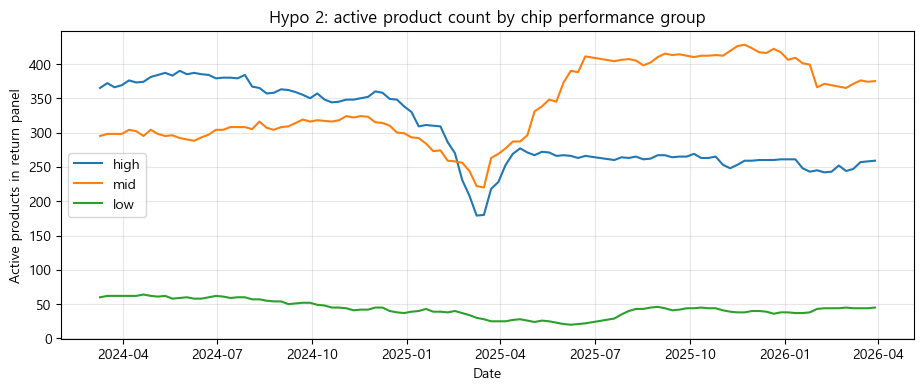

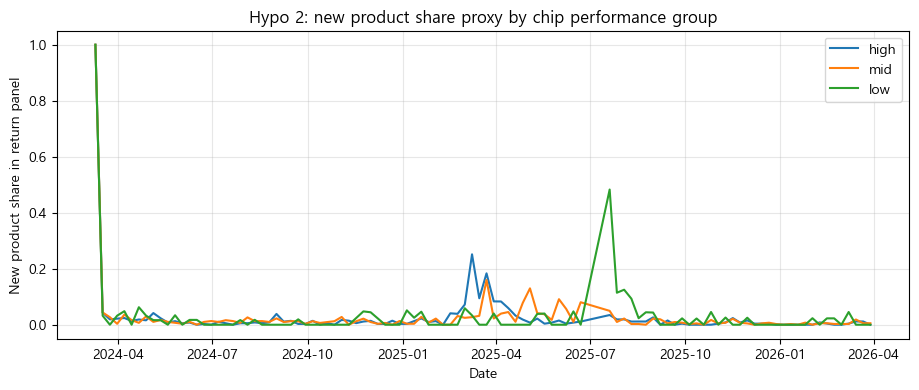

In [3]:
# 0-1. VRAM proxy mismatch and product-composition diagnostics

# VRAM proxy가 chip 성능군과 얼마나 일치하는지 확인
meta_g = gpu_meta[
    gpu_meta["chip_perf_group"].isin(GROUPS)
    & gpu_meta["h2_perf_group"].isin(GROUPS)
].copy()

vram_chip_n = (
    pd.crosstab(meta_g["chip_perf_group"], meta_g["h2_perf_group"])
      .reindex(index=GROUPS, columns=GROUPS, fill_value=0)
)
vram_chip_pct = vram_chip_n.div(vram_chip_n.sum(axis=1).replace(0, np.nan), axis=0)

vram_mis = pd.DataFrame([{
    "product_n": len(meta_g),
    "matched_chip_vram_group_n": int((meta_g["chip_perf_group"] == meta_g["h2_perf_group"]).sum()),
    "mismatched_chip_vram_group_n": int((meta_g["chip_perf_group"] != meta_g["h2_perf_group"]).sum()),
    "mismatch_rate": float((meta_g["chip_perf_group"] != meta_g["h2_perf_group"]).mean()),
}])

print("chip performance group × VRAM proxy group, count")
display(vram_chip_n)
print("chip performance group × VRAM proxy group, row percentage")
display(vram_chip_pct.round(3))
print("VRAM proxy mismatch summary")
display(vram_mis.round(4))

# 제품 단위 패널에서 각 성능군별 활성 제품 수와 신규 진입 제품 수를 계산
comp_panel = panel_gpu[panel_gpu["chip_perf_group"].isin(GROUPS)].copy()

first_w = (
    comp_panel.groupby(["row_id", "chip_perf_group"], as_index=False)["date"]
              .min()
              .rename(columns={"date": "date"})
)

active = (
    comp_panel.groupby(["date", "chip_perf_group"], as_index=False)["row_id"]
              .nunique()
              .rename(columns={"row_id": "active_product_n"})
)

new_prod = (
    first_w.groupby(["date", "chip_perf_group"], as_index=False)["row_id"]
              .nunique()
              .rename(columns={"row_id": "new_product_n"})
)

comp_diag = active.merge(new_prod, on=["date", "chip_perf_group"], how="left")
comp_diag["new_product_n"] = comp_diag["new_product_n"].fillna(0)
comp_diag["new_product_share"] = comp_diag["new_product_n"] / comp_diag["active_product_n"].replace(0, np.nan)
comp_diag["log_active_product_n"] = np.log1p(comp_diag["active_product_n"])

# gap_week: adjacent match 수와 bridge gap 수를 이용해 지수 구성 안정성 proxy 생성
gap_c = gap_week.rename(columns={"group": "chip_perf_group"}).copy()
gap_c["bridge_ratio"] = gap_c["bridge_n"] / gap_c["adj_n"].replace(0, np.nan)

comp_diag = comp_diag.merge(
    gap_c[["date", "chip_perf_group", "adj_n", "bridge_n", "bridge_ratio"]],
    on=["date", "chip_perf_group"],
    how="left",
)

comp_sum = (
    comp_diag.groupby("chip_perf_group")
    .agg(
        mean_active_product_n=("active_product_n", "mean"),
        median_active_product_n=("active_product_n", "median"),
        max_new_product_share=("new_product_share", "max"),
        mean_new_product_share=("new_product_share", "mean"),
        max_bridge_ratio=("bridge_ratio", "max"),
        mean_bridge_ratio=("bridge_ratio", "mean"),
    )
    .reset_index()
)

print("product-composition diagnostic summary")
display(comp_sum.round(4))

plt.figure(figsize=(11, 4))
for g in GROUPS:
    sub = comp_diag[comp_diag["chip_perf_group"] == g]
    plt.plot(sub["date"], sub["active_product_n"], label=g)
plt.title("Hypo 2: active product count by chip performance group")
plt.xlabel("Date")
plt.ylabel("Active products in return panel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(11, 4))
for g in GROUPS:
    sub = comp_diag[comp_diag["chip_perf_group"] == g]
    plt.plot(sub["date"], sub["new_product_share"], label=g)
plt.title("Hypo 2: new product share proxy by chip performance group")
plt.xlabel("Date")
plt.ylabel("New product share in return panel")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

vram_chip_n.to_csv(H2_DIR / "vram_chip_n.csv")
vram_chip_pct.to_csv(H2_DIR / "vram_chip_pct.csv")
vram_mis.to_csv(H2_DIR / "vram_mismatch.csv", index=False)
comp_diag.to_csv(H2_DIR / "comp_diag.csv", index=False)
comp_sum.to_csv(H2_DIR / "comp_sum.csv", index=False)

<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: VRAM proxy 불일치와 제품구성 변화</mark></b></span><br><br>
<b>[VRAM proxy 불일치]</b><br>
chip 성능군과 VRAM proxy가 일치하지 않는 제품은 492개이며, 불일치율은 24.9%이다. 특히 chip 기준 mid 제품 중 33.0%가 VRAM 기준 high로 들어가고, chip 기준 low 제품 중 37.2%가 VRAM 기준 mid로 들어간다. 따라서 VRAM 분석은 성능군 본분석이 아니라 보조 proxy로만 해석해야 한다.<br><br>
<b>[제품구성 변화]</b><br>
평균 활성 제품 수는 high 303.4개, mid 338.2개, low 43.7개이다. mean new product share는 세 그룹 모두 약 2.7~2.9% 수준이지만, low 그룹의 mean bridge ratio가 1.05%로 high 0.46%와 mid 0.49%보다 높다. 이는 low 그룹이 재고/관측 불안정성에 더 민감할 수 있음을 뜻한다.<br><br>
<b>[해석상 반영]</b><br>
이 진단 때문에 Hypo 2 결론은 단일 회귀만으로 판단하지 않고, 뒤에서 composition-control robustness와 product FE robustness까지 함께 확인한다. 신제품 출시일 더미를 외부에서 임의로 넣지는 않았지만, 데이터 내부의 활성 제품 수·신규 진입 비율·bridge ratio를 통해 제품구성 변화의 영향을 보조 통제했다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>1. 성능군별 가격지수와 주간 수익률 EDA</mark></b></span><br><br>

<b>[왜 이 과정을 하는가]</b><br>
회귀분석에 들어가기 전에 high/mid/low 가격지수가 서로 어떤 방향으로 움직였는지 확인한다. 가격지수 level은 설명용이고, 통계 검정은 주간 로그수익률을 사용한다.<br><br>

<b>[해석 기준]</b><br>
• index plot은 성능군별 누적 가격 흐름을 보여준다.<br>
• return plot은 BTC와 결합하기 전 각 성능군의 단기 변동성을 확인한다.<br>
• 특정 성능군만 극단적으로 변동하거나 장기간 결측이 많으면 이후 상호작용 회귀 결과를 해석할 때 주의한다.<br><br>

<b>[주의]</b><br>
가격지수 level이 같이 상승한다고 해서 BTC와의 관계를 바로 주장하면 안 된다. 추세로 인한 허위 상관을 피하기 위해 가설 검정은 <b>ret_chip_w의 주간 로그수익률</b>로 수행한다.
</div>

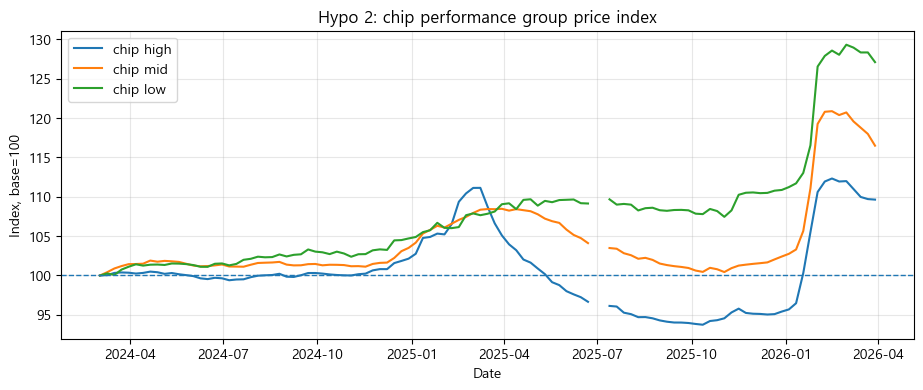

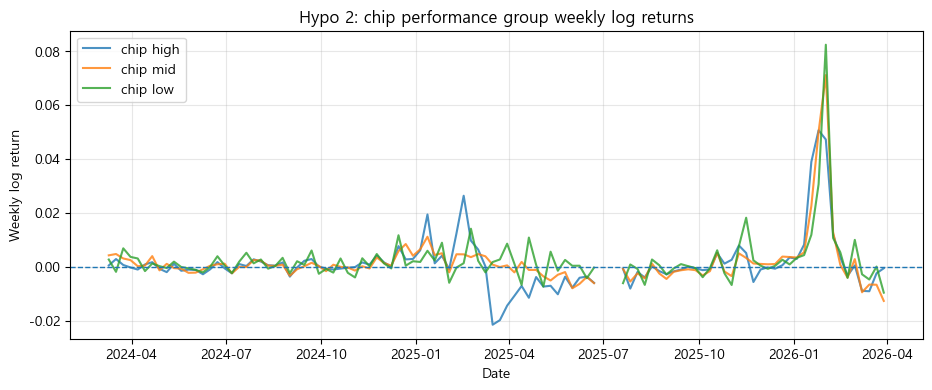

chip group return summary


,group,count,mean,std,min,median,max
0,high,105.0,0.00093,0.00991,-0.02155,-0.00028,0.05057
1,mid,105.0,0.00151,0.00950,-0.01272,0.00028,0.07104
2,low,105.0,0.00224,0.00955,-0.00965,0.00065,0.08230


In [4]:
# ============================================================
# 1. 성능군별 가격지수와 주간 수익률 EDA
# ============================================================

chip_cols = [g for g in GROUPS if g in ret_chip_w.columns]
vram_cols = [g for g in GROUPS if g in ret_vram_w.columns]

plt.figure(figsize=(11, 4))
for g in chip_cols:
    plt.plot(idx_chip_w.index, idx_chip_w[g], label=f"chip {g}")
plt.axhline(100, linestyle="--", linewidth=1)
plt.title("Hypo 2: chip performance group price index")
plt.xlabel("Date")
plt.ylabel("Index, base=100")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(11, 4))
for g in chip_cols:
    plt.plot(ret_chip_w.index, ret_chip_w[g], label=f"chip {g}", alpha=0.8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Hypo 2: chip performance group weekly log returns")
plt.xlabel("Date")
plt.ylabel("Weekly log return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

chip_ret = (
    ret_chip_w[chip_cols]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "group"})
)

print("chip group return summary")
display(chip_ret.round(5))
chip_ret.to_csv(H2_DIR / "chip_ret.csv", index=False)

<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: 성능군별 수익률 EDA</mark></b></span><br><br>
<b>[평균과 변동성]</b><br>
chip 기준 주간 로그수익률 평균은 high 0.0009, mid 0.0015, low 0.0022이다. 표준편차는 high 0.0099, mid 0.0095, low 0.0096로 세 그룹이 비슷하다.<br><br>
<b>[가설 방향성 점검]</b><br>
단순 평균만 보면 오히려 low 그룹의 평균 수익률이 가장 높고 high 그룹이 가장 낮다. 따라서 EDA만으로는 '고성능 GPU가 더 강하게 상승한다'는 방향성이 보이지 않는다. 또한 Hypo 2의 핵심은 평균 수익률 차이가 아니라 BTC에 대한 반응계수 차이이므로, 이 결과는 상호작용 회귀로 넘어가기 전의 탐색적 확인으로만 둔다.<br><br>
<b>[극단값 주의]</b><br>
max weekly return은 high 0.0506, mid 0.0710, low 0.0823로 low/mid에서 더 큰 값이 관찰된다. low 그룹 제품 수가 작기 때문에 일부 제품 구성 변화가 그룹 수익률에 크게 반영될 가능성이 있다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>2. Phase 1: One-way ANOVA / Welch ANOVA 탐색 분석</mark></b></span><br><br>

<b>[왜 이 기법을 쓰는가]</b><br>
슬라이드의 Phase 1은 성능군별 평균 반응도가 다르게 나타나는지 먼저 탐색하는 단계이다. 따라서 high/mid/low의 주간 로그수익률 평균이 서로 다른지 One-way ANOVA로 확인한다.<br><br>

<b>[Levene 검정과 Welch ANOVA]</b><br>
성능군별 수익률 분산이 같다는 보장이 없으므로 먼저 Levene 검정으로 등분산성을 확인한다. 등분산성이 약하면 일반 ANOVA보다 <b>Welch ANOVA</b>를 우선 참고한다.<br><br>

<b>[중요한 한계]</b><br>
이 ANOVA는 BTC 변동, 환율, NVDA 수익률을 통제하지 않는다. 또한 동일 주차의 high/mid/low 수익률은 공통 시장 충격을 공유한다. 따라서 이 단계는 최종 가설 검정이 아니라 <b>탐색적 차이 확인</b>으로만 사용한다.<br><br>

<b>[실행 후 해석]</b><br>
ANOVA p-value가 유의하면 성능군별 평균 변동률 자체가 다를 수 있다는 신호이다. 그러나 Hypo 2의 핵심은 평균 차이가 아니라 <b>BTC에 대한 민감도 차이</b>이므로 최종 결론은 다음 상호작용 회귀에서 판단한다.
</div>

ANOVA / Welch ANOVA results


,block,test,stat,p_value,note
0,chip_main,Levene_median,0.39014,0.67729,H0: equal variances
1,chip_main,One_way_ANOVA,0.48481,0.61627,H0: equal group means
2,chip_main,Welch_ANOVA,0.47715,0.62123,"H0: equal group means, unequal variance allowed"
3,vram_proxy,Levene_median,5.68271,0.00377,H0: equal variances
4,vram_proxy,One_way_ANOVA,0.25420,0.77569,H0: equal group means
5,vram_proxy,Welch_ANOVA,0.33437,0.71628,"H0: equal group means, unequal variance allowed"


<Figure size 800x400 with 0 Axes>

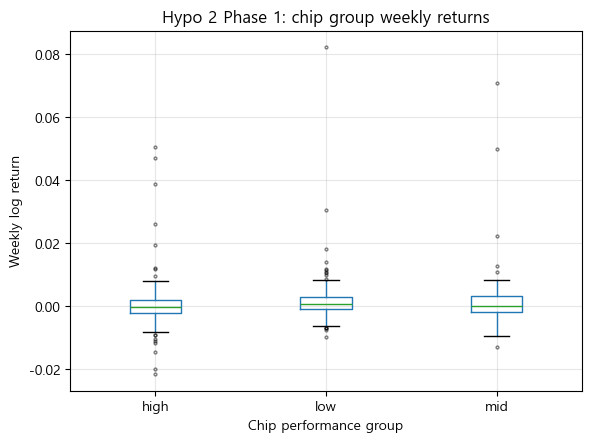

In [6]:
# 2. One-way ANOVA / Welch ANOVA: 그룹 평균 수익률 차이 탐색

def run_anova(ret_w, cols, block_name):
    samples = [ret_w[g].dropna().to_numpy(float) for g in cols]
    labels = cols

    levene_stat, levene_p = stats.levene(*samples, center="median")
    f_stat, f_p = stats.f_oneway(*samples)
    welch = anova_oneway(samples, use_var="unequal")

    out = pd.DataFrame([
        {"block": block_name, "test": "Levene_median", "stat": levene_stat, "p_value": levene_p, "note": "H0: equal variances"},
        {"block": block_name, "test": "One_way_ANOVA", "stat": f_stat, "p_value": f_p, "note": "H0: equal group means"},
        {"block": block_name, "test": "Welch_ANOVA", "stat": welch.statistic, "p_value": welch.pvalue, "note": "H0: equal group means, unequal variance allowed"},
    ])

    long = (
        ret_w[cols]
        .reset_index()
        .melt(id_vars="date", value_vars=cols, var_name="group", value_name="gpu_ret")
        .dropna()
    )

    return out, long

anova_chip, chip_long_anova = run_anova(ret_chip_w, chip_cols, "chip_main")
anova_vram, vram_long_anova = run_anova(ret_vram_w, vram_cols, "vram_proxy")
anova_results = pd.concat([anova_chip, anova_vram], ignore_index=True)

print("ANOVA / Welch ANOVA results")
display(anova_results.round(5))
anova_results.to_csv(H2_DIR / "anova.csv", index=False)

plt.figure(figsize=(8, 4))
chip_long_anova.boxplot(column="gpu_ret", by="group", flierprops={
        "marker": "o",
        "markersize": 2,
        "alpha": 0.5,
    })
plt.title("Hypo 2 Phase 1: chip group weekly returns")
plt.suptitle("")
plt.xlabel("Chip performance group")
plt.ylabel("Weekly log return")
plt.grid(True, alpha=0.3)
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: ANOVA / Welch ANOVA</mark></b></span><br><br>
<b>[chip 기준]</b><br>
chip 기준 Levene 검정 p-value는 0.677로 등분산 가정을 강하게 위반한다고 보기 어렵다. One-way ANOVA p-value는 0.616, Welch ANOVA p-value는 0.621로 모두 유의하지 않다. 즉 high/mid/low의 평균 주간 수익률 차이는 통계적으로 확인되지 않는다.<br><br>
<b>[VRAM 기준]</b><br>
VRAM 기준 Levene p-value는 0.0038로 등분산성이 약하다. 이 경우 Welch ANOVA를 우선 보아야 하는데, Welch p-value는 0.716로 역시 유의하지 않다.<br><br>
<b>[결론]</b><br>
Phase 1 탐색 분석에서는 성능군별 평균 변동률 자체가 다르다는 근거가 없다. 따라서 Hypo 2를 지지하려면 평균 차이가 아니라 BTC × 성능군 상호작용항에서 별도 근거가 나와야 한다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>3. Phase 2 데이터셋 구성: BTC × 성능군 상호작용</mark></b></span><br><br>

<b>[왜 long-form panel로 바꾸는가]</b><br>
Hypo 2는 high, mid, low 세 개의 수익률 시계열을 비교하는 문제이다. 따라서 wide-form을 <b>date / group / gpu_ret</b> 형태로 바꿔야 성능군 dummy와 BTC 수익률의 상호작용항을 만들 수 있다.<br><br>

<b>[핵심 변수]</b><br>
• <b>btc_krw_ret_l0 ~ btc_krw_ret_l8</b>: BTC 변동이 즉시 또는 지연되어 성능군별 GPU 가격에 반영되는지 확인한다.<br>
• <b>high_btc_lk</b>: k주 lag BTC 수익률에 대한 high 그룹의 추가 민감도이다. low 그룹이 기준이다.<br>
• <b>mid_btc_lk</b>: k주 lag BTC 수익률에 대한 mid 그룹의 추가 민감도이다.<br>
• <b>high_nvda_ret, mid_nvda_ret</b>: AI/반도체 수요가 성능군별로 다르게 작용할 수 있으므로 추가 통제한다.<br>
• <b>gpu_ret_l1</b>: 각 성능군 가격 수익률의 자기시차를 통제한다.<br>
• <b>composition controls</b>: 제품 진입/활성 제품 수/bridge gap 비율은 본모형에는 바로 넣지 않고, 신제품·표본구성 효과를 점검하는 강건성 분석에서 추가한다.<br><br>

<b>[해석 기준]</b><br>
• high_btc 계수들이 양수이고 공동으로 유의하면 high GPU가 low GPU보다 BTC 변화에 더 민감하다는 근거가 된다.<br>
• mid_btc 계수들은 mid GPU와 low GPU의 민감도 차이를 의미한다.
</div>

In [7]:
# 3. H2 interaction regression dataset 생성 함수

def make_reg_df(ret_w, block_name, cols):
    long = (
        ret_w[cols]
        .reset_index()
        .melt(id_vars="date", value_vars=cols, var_name="group", value_name="gpu_ret")
        .dropna(subset=["gpu_ret"])
        .sort_values(["group", "date"])
        .copy()
    )

    # Hypo 1에서 만든 BTC/FX/NVDA 및 BTC lag 변수 결합
    dat = long.merge(mkt.reset_index().rename(columns={mkt.index.name or "index": "date"}), on="date", how="inner")
    dat = dat.sort_values(["group", "date"]).copy()

    # group별 자기시차
    dat["gpu_ret_l1"] = dat.groupby("group")["gpu_ret"].shift(1)

    # low를 기준으로 high/mid 추가 민감도 해석
    dat["is_high"] = (dat["group"] == "high").astype(int)
    dat["is_mid"] = (dat["group"] == "mid").astype(int)

    btc_lags = [f"btc_krw_ret_l{k}" for k in range(L + 1)]
    for col in btc_lags:
        lag = col.replace("btc_krw_ret_l", "")
        dat[f"high_btc_l{lag}"] = dat["is_high"] * dat[col]
        dat[f"mid_btc_l{lag}"] = dat["is_mid"] * dat[col]

    dat["high_nvda_ret"] = dat["is_high"] * dat["nvda_ret"]
    dat["mid_nvda_ret"] = dat["is_mid"] * dat["nvda_ret"]
    dat["high_fx_ret"] = dat["is_high"] * dat["fx_ret"]
    dat["mid_fx_ret"] = dat["is_mid"] * dat["fx_ret"]

    dat["block"] = block_name
    return dat

h2_chip = make_reg_df(ret_chip_w, "chip_main", chip_cols)
h2_vram = make_reg_df(ret_vram_w, "vram_proxy", vram_cols)

btc_lags = [f"btc_krw_ret_l{k}" for k in range(L + 1)]
hi_btc = [f"high_btc_l{k}" for k in range(L + 1)]
mid_btc = [f"mid_btc_l{k}" for k in range(L + 1)]

model_cols = (
    ["gpu_ret", "date", "group", "is_high", "is_mid"]
    + btc_lags
    + hi_btc
    + mid_btc
    + ["fx_ret", "nvda_ret", "high_fx_ret", "mid_fx_ret", "high_nvda_ret", "mid_nvda_ret", "gpu_ret_l1"]
)

chip_reg = h2_chip[model_cols].dropna().copy()
vram_reg = h2_vram[model_cols].dropna().copy()

print("H2 chip regression dataset")
display(chip_reg.head())
print("H2 VRAM proxy regression dataset")
display(vram_reg.head())

sample_check = pd.DataFrame([
    {"block": "chip_main", "raw_rows": len(h2_chip), "complete_reg_rows": len(chip_reg), "week_n": chip_reg["date"].nunique()},
    {"block": "vram_proxy", "raw_rows": len(h2_vram), "complete_reg_rows": len(vram_reg), "week_n": vram_reg["date"].nunique()},
])

print("H2 sample check")
display(sample_check)

h2_chip.to_csv(H2_DIR / "chip_raw.csv", index=False)
chip_reg.to_csv(H2_DIR / "chip_reg.csv", index=False)
h2_vram.to_csv(H2_DIR / "vram_raw.csv", index=False)
vram_reg.to_csv(H2_DIR / "vram_reg.csv", index=False)
sample_check.to_csv(H2_DIR / "sample.csv", index=False)

H2 chip regression dataset


,gpu_ret,date,group,is_high,is_mid,btc_krw_ret_l0,btc_krw_ret_l1,btc_krw_ret_l2,btc_krw_ret_l3,btc_krw_ret_l4,...,mid_btc_l6,mid_btc_l7,mid_btc_l8,fx_ret,nvda_ret,high_fx_ret,mid_fx_ret,high_nvda_ret,mid_nvda_ret,gpu_ret_l1
8,-0.002043,2024-05-05,high,1,0,-0.051308,0.011898,-0.061172,0.017280,-0.028035,...,-0.0,0.0,0.0,0.000705,0.047370,0.000705,0.0,0.047370,0.0,-0.000792
9,0.001045,2024-05-12,high,1,0,-0.001375,-0.051308,0.011898,-0.061172,0.017280,...,0.0,-0.0,0.0,-0.012364,0.045296,-0.012364,-0.0,0.045296,0.0,-0.002043
10,-0.001546,2024-05-19,high,1,0,0.046114,-0.001375,-0.051308,0.011898,-0.061172,...,-0.0,0.0,-0.0,0.000546,0.025037,0.000546,0.0,0.025037,0.0,0.001045
11,-0.001123,2024-05-26,high,1,0,0.068650,0.046114,-0.001375,-0.051308,0.011898,...,0.0,-0.0,0.0,0.002116,0.066018,0.002116,0.0,0.066018,0.0,-0.001546
12,-0.001235,2024-06-02,high,1,0,-0.010918,0.068650,0.046114,-0.001375,-0.051308,...,-0.0,0.0,-0.0,0.003688,0.125593,0.003688,0.0,0.125593,0.0,-0.001123


H2 VRAM proxy regression dataset


,gpu_ret,date,group,is_high,is_mid,btc_krw_ret_l0,btc_krw_ret_l1,btc_krw_ret_l2,btc_krw_ret_l3,btc_krw_ret_l4,...,mid_btc_l6,mid_btc_l7,mid_btc_l8,fx_ret,nvda_ret,high_fx_ret,mid_fx_ret,high_nvda_ret,mid_nvda_ret,gpu_ret_l1
8,-0.001819,2024-05-05,high,1,0,-0.051308,0.011898,-0.061172,0.017280,-0.028035,...,-0.0,0.0,0.0,0.000705,0.047370,0.000705,0.0,0.047370,0.0,-0.001028
9,0.001052,2024-05-12,high,1,0,-0.001375,-0.051308,0.011898,-0.061172,0.017280,...,0.0,-0.0,0.0,-0.012364,0.045296,-0.012364,-0.0,0.045296,0.0,-0.001819
10,-0.001710,2024-05-19,high,1,0,0.046114,-0.001375,-0.051308,0.011898,-0.061172,...,-0.0,0.0,-0.0,0.000546,0.025037,0.000546,0.0,0.025037,0.0,0.001052
11,-0.001190,2024-05-26,high,1,0,0.068650,0.046114,-0.001375,-0.051308,0.011898,...,0.0,-0.0,0.0,0.002116,0.066018,0.002116,0.0,0.066018,0.0,-0.001710
12,-0.001754,2024-06-02,high,1,0,-0.010918,0.068650,0.046114,-0.001375,-0.051308,...,-0.0,0.0,-0.0,0.003688,0.125593,0.003688,0.0,0.125593,0.0,-0.001190


H2 sample check


,block,raw_rows,complete_reg_rows,week_n
0,chip_main,315,291,97
1,vram_proxy,315,291,97


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>4. H2 메인 검정: 성능군별 BTC 민감도 차이</mark></b></span><br><br>

<b>[모형 구조]</b><br>
종속변수는 성능군별 주간 GPU 로그수익률이다. 설명변수에는 BTC lag 0~8주, high/mid 성능군 dummy, 그리고 BTC lag × high/mid 상호작용을 넣는다. 기준 그룹은 low이다.<br><br>

<b>[왜 이 회귀가 Hypo 2의 본 검정인가]</b><br>
가설 2는 “high GPU 가격이 더 올랐다”가 아니라 “BTC 변화에 대한 high GPU의 반응계수가 더 크다”는 주장이다. 따라서 평균 비교가 아니라 <b>BTC × 성능군 상호작용항</b>이 직접 검정 대상이다.<br><br>

<b>[통제변수]</b><br>
• <b>fx_ret</b>: 원화 가격에 반영되는 환율 효과 통제<br>
• <b>nvda_ret</b>: AI/반도체 수요 proxy 통제<br>
• <b>NVDA × 성능군</b>: AI 수요가 고성능 GPU에 더 강하게 작용할 수 있음을 통제<br>
• <b>gpu_ret_l1</b>: 성능군별 가격 수익률의 단기 관성 통제<br><br>

<b>[표준오차]</b><br>
같은 주차의 high/mid/low 수익률은 공통 시장 충격을 공유하므로, 표준오차는 <b>date 기준 cluster-robust</b>로 계산한다.<br><br>

<b>[실행 후 해석]</b><br>
• <b>high_btc_l0 ~ high_btc_l8 공동 유의성</b>: high 그룹이 low 그룹보다 BTC에 다르게 반응하는지 확인<br>
• <b>cumulative high-low effect</b>: 0~8주 전체 BTC 반응의 누적 차이가 양수인지 확인<br>
• 이 값이 양수이고 유의하면 Hypo 2를 지지하는 핵심 근거가 된다.<br>
• BTC lag를 0~8주까지 모두 넣었기 때문에 개별 lag 계수의 p-value만으로 결론을 내리면 안 된다. 본문에서는 <b>공동 유의성 검정</b>과 <b>0~8주 누적 효과</b>를 최종 판단 기준으로 둔다.<br>
• 정확한 출시일 더미가 없으므로 신제품 효과는 본모형의 한계로 남긴다. 대신 뒤에서 제품구성 proxy를 통제하는 강건성 분석을 별도로 수행한다.
</div>

In [8]:
# 4. H2 interaction regression model

x_cols = (
    ["is_high", "is_mid"]
    + btc_lags
    + hi_btc
    + mid_btc
    + ["fx_ret", "nvda_ret", "high_fx_ret", "mid_fx_ret", "high_nvda_ret", "mid_nvda_ret", "gpu_ret_l1"]
)


def fit_int(dat, block_name):
    y = dat["gpu_ret"].astype(float)
    X = sm.add_constant(dat[x_cols].astype(float))

    model = sm.OLS(y, X).fit(
        cov_type="cluster",
        cov_kwds={"groups": dat["date"]}
    )

    coef = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "se": model.bse.values,
        "t": model.tvalues.values,
        "p_value": model.pvalues.values,
        "block": block_name,
    })
    return model, coef


chip_mod, chip_coef = fit_int(chip_reg, "chip_main")
vram_mod, vram_coef = fit_int(vram_reg, "vram_proxy")

print(chip_mod.summary())
print("chip main coefficient table")
display(chip_coef.round(5))

chip_coef.to_csv(H2_DIR / "chip_coef.csv", index=False)
vram_coef.to_csv(H2_DIR / "vram_coef.csv", index=False)

                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     3.435
Date:                Sun, 03 May 2026   Prob (F-statistic):           8.05e-07
Time:                        19:03:58   Log-Likelihood:                 1012.3
No. Observations:                 291   AIC:                            -1951.
Df Residuals:                     254   BIC:                            -1815.
Df Model:                          36                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0008      0.001      1.

,term,coef,se,t,p_value,block
0,const,0.00079,0.00071,1.11430,0.26515,chip_main
1,is_high,-0.00063,0.00080,-0.78025,0.43524,chip_main
2,is_mid,-0.00045,0.00056,-0.80266,0.42217,chip_main
3,btc_krw_ret_l0,0.00112,0.01944,0.05736,0.95426,chip_main
4,btc_krw_ret_l1,-0.00298,0.02050,-0.14519,0.88456,chip_main
5,btc_krw_ret_l2,0.04393,0.03034,1.44803,0.14761,chip_main
6,btc_krw_ret_l3,-0.01838,0.01577,-1.16525,0.24392,chip_main
7,btc_krw_ret_l4,-0.00331,0.02477,-0.13349,0.89380,chip_main
8,btc_krw_ret_l5,0.00240,0.01472,0.16301,0.87051,chip_main
9,btc_krw_ret_l6,-0.01318,0.02056,-0.64117,0.52141,chip_main


<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: 상호작용 회귀계수 1차 확인</mark></b></span><br><br>
<b>[chip 기준 개별 상호작용항]</b><br>
chip 기준 high_btc_l0~l8과 mid_btc_l0~l8의 개별 p-value는 10% 수준에서도 안정적으로 유의하지 않았다. high 관련 계수는 부호도 양수와 음수가 섞여 있어, 특정 시차에서만 우연히 나타난 신호를 가설 지지로 해석하기 어렵다.<br><br>
<b>[VRAM 기준 개별 상호작용항]</b><br>
VRAM 기준에서는 mid_btc_l7이 p-value 0.00036으로 유의하고, high_btc_l2가 10% 수준에서 약하게 나타난다. 하지만 이는 VRAM proxy 기준의 개별 lag 신호일 뿐이며, chip 기준 본분석에서는 재현되지 않는다. 따라서 최종 판단은 다음 셀의 공동 유의성 및 누적 효과 검정에 둔다.<br><br>
<b>[해석 원칙]</b><br>
lag 0~8주를 동시에 넣은 모델에서는 개별 coefficient의 p-value보다 joint test와 cumulative effect가 더 중요하다. 이 셀은 회귀가 정상적으로 구성되었고 상호작용항들이 어떤 방향으로 분포하는지 확인하는 단계이다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5. BTC × 성능군 상호작용항의 공동 유의성 및 누적 효과 검정</mark></b></span><br><br>

<b>[왜 공동 유의성 검정이 필요한가]</b><br>
BTC 반응은 특정 한 주 lag에서만 나타날 수도 있고, 여러 lag에 나누어 약하게 나타날 수도 있다. 따라서 개별 p-value만 보는 것보다 <b>BTC lag 0~8주 상호작용항 전체가 공동으로 0인지</b> 검정해야 한다.<br><br>

<b>[검정 내용]</b><br>
• <b>high interaction joint test</b>: high 그룹의 BTC 민감도가 low 그룹과 같은가?<br>
• <b>mid interaction joint test</b>: mid 그룹의 BTC 민감도가 low 그룹과 같은가?<br>
• <b>all interaction joint test</b>: 성능군별 BTC 민감도 차이가 전체적으로 존재하는가?<br>
• <b>cumulative effect</b>: 0~8주 BTC 반응계수를 합산했을 때 low/mid/high 중 어느 그룹이 가장 크게 반응하는가?<br><br>

<b>[실행 후 해석]</b><br>
Hypo 2를 지지하려면 단순히 high 계수가 하나 양수인 정도가 아니라, <b>high-low 누적 차이</b>가 양수이고 공동 유의성 또는 누적 효과 검정에서 통계적 근거가 있어야 한다. 과도한 lag 변수로 인해 개별 계수의 표준오차가 커질 수 있으므로, 개별 lag의 유의성은 보조적으로만 본다.
</div>

In [9]:
# 5. Joint tests and cumulative effects

def joint_test(model, terms, label, block):
    names = list(model.params.index)
    R = np.zeros((len(terms), len(names)))
    for i, term in enumerate(terms):
        R[i, names.index(term)] = 1.0
    test = model.f_test(R)
    return {
        "block": block,
        "test": label,
        "F_stat": float(np.asarray(test.fvalue).ravel()[0]),
        "p_value": float(np.asarray(test.pvalue).ravel()[0]),
        "df_num": float(test.df_num),
        "df_denom": float(test.df_denom),
    }


def cum_test(model, terms, label, block):
    names = list(model.params.index)
    R = np.zeros((1, len(names)))
    for term in terms:
        R[0, names.index(term)] += 1.0
    test = model.t_test(R)
    return {
        "block": block,
        "test": label,
        "estimate": float(np.asarray(test.effect).ravel()[0]),
        "se": float(np.asarray(test.sd).ravel()[0]),
        "t": float(np.asarray(test.tvalue).ravel()[0]),
        "p_value": float(np.asarray(test.pvalue).ravel()[0]),
    }


def h2_test_block(model, block):
    joint_rows = [
        joint_test(model, hi_btc, "high_vs_low_BTC_lags_joint_zero", block),
        joint_test(model, mid_btc, "mid_vs_low_BTC_lags_joint_zero", block),
        joint_test(model, hi_btc + mid_btc, "all_group_BTC_interactions_joint_zero", block),
    ]

    # 누적 BTC 민감도: low는 base BTC lag 합, high/mid는 base + interaction 합
    cumulative_rows = [
        cum_test(model, btc_lags, "low_cumulative_BTC_effect", block),
        cum_test(model, btc_lags + hi_btc, "high_cumulative_BTC_effect", block),
        cum_test(model, btc_lags + mid_btc, "mid_cumulative_BTC_effect", block),
        cum_test(model, hi_btc, "high_minus_low_cumulative_BTC_effect", block),
        cum_test(model, mid_btc, "mid_minus_low_cumulative_BTC_effect", block),
    ]
    return pd.DataFrame(joint_rows), pd.DataFrame(cumulative_rows)

joint_chip, cumulative_chip = h2_test_block(chip_mod, "chip_main")
joint_vram, cumulative_vram = h2_test_block(vram_mod, "vram_proxy")

main_joint = pd.concat([joint_chip, joint_vram], ignore_index=True)
main_cum = pd.concat([cumulative_chip, cumulative_vram], ignore_index=True)

print("H2 BTC interaction joint tests")
display(main_joint.round(5))
print("H2 cumulative BTC effects")
display(main_cum.round(5))

main_joint.to_csv(H2_DIR / "joint.csv", index=False)
main_cum.to_csv(H2_DIR / "cum.csv", index=False)

H2 BTC interaction joint tests


,block,test,F_stat,p_value,df_num,df_denom
0,chip_main,high_vs_low_BTC_lags_joint_zero,0.45585,0.90043,9.0,96.0
1,chip_main,mid_vs_low_BTC_lags_joint_zero,1.01484,0.43381,9.0,96.0
2,chip_main,all_group_BTC_interactions_joint_zero,0.88121,0.60176,18.0,96.0
3,vram_proxy,high_vs_low_BTC_lags_joint_zero,0.97570,0.46504,9.0,96.0
4,vram_proxy,mid_vs_low_BTC_lags_joint_zero,2.48160,0.01360,9.0,96.0
5,vram_proxy,all_group_BTC_interactions_joint_zero,1.65144,0.06249,18.0,96.0


H2 cumulative BTC effects


,block,test,estimate,se,t,p_value
0,chip_main,low_cumulative_BTC_effect,0.05189,0.03859,1.34472,0.17872
1,chip_main,high_cumulative_BTC_effect,0.03759,0.03080,1.22030,0.22235
2,chip_main,mid_cumulative_BTC_effect,0.04470,0.02561,1.74544,0.08091
3,chip_main,high_minus_low_cumulative_BTC_effect,-0.01430,0.03669,-0.38969,0.69677
4,chip_main,mid_minus_low_cumulative_BTC_effect,-0.00719,0.02713,-0.26488,0.79110
5,vram_proxy,low_cumulative_BTC_effect,-0.00093,0.01994,-0.04668,0.96277
6,vram_proxy,high_cumulative_BTC_effect,0.04795,0.03453,1.38875,0.16491
7,vram_proxy,mid_cumulative_BTC_effect,0.04897,0.02907,1.68469,0.09205
8,vram_proxy,high_minus_low_cumulative_BTC_effect,0.04888,0.04099,1.19242,0.23310
9,vram_proxy,mid_minus_low_cumulative_BTC_effect,0.04990,0.03464,1.44069,0.14967


<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: BTC × 성능군 공동 유의성 및 누적효과</mark></b></span><br><br>
<b>[chip 본분석]</b><br>
chip 기준 high-vs-low BTC interaction 공동검정 p-value는 0.900, mid-vs-low는 0.434, 전체 상호작용항은 0.602이다. 모두 유의하지 않으므로, 성능군별 BTC 민감도 차이가 존재한다고 보기 어렵다.<br><br>
<b>[chip 누적효과]</b><br>
0~8주 누적 BTC 효과의 high-minus-low 추정치는 -0.0143, p-value는 0.697이다. 추정치가 음수이므로 가설 방향과도 맞지 않는다. mid-minus-low도 -0.0072, p-value 0.791로 유의하지 않다.<br><br>
<b>[VRAM proxy]</b><br>
VRAM 기준에서는 mid-vs-low 공동검정 p-value가 0.0136로 유의하고 전체 상호작용항도 p-value 0.062로 약한 신호가 있다. 그러나 high-vs-low는 p-value 0.465로 유의하지 않고, high-minus-low 누적효과도 p-value 0.233로 유의하지 않다. 따라서 VRAM 결과는 '고성능 high가 더 민감하다'는 직접 근거가 아니라 제한적 보조 신호이다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5-1. 신제품·표본구성 효과 보완: composition-control robustness</mark></b></span><br><br>

<b>[수용한 피드백]</b><br>
신제품 출시나 단종은 high GPU 가격에 불연속적인 충격을 만들 수 있다. 다만 정확한 출시일 더미를 외부에서 임의로 넣으면 주관적 선택이 들어간다. 따라서 본분석 계수는 유지하되, 이미 생성된 데이터에서 관측되는 제품구성 변화 proxy를 통제한 강건성 회귀를 추가한다.<br><br>

<b>[추가 통제변수]</b><br>
• <b>log_active_product_n</b>: 해당 주차·성능군에서 수익률 패널에 들어온 활성 제품 수<br>
• <b>new_product_share</b>: 해당 주차·성능군에서 처음 관측된 제품 비율, 신제품/표본 진입 proxy<br>
• <b>bridge_ratio</b>: 전주에는 빠졌다가 전전주와 현재에 관측된 bridge gap 비율, 재고/관측 불안정성 proxy<br><br>

<b>[해석 기준]</b><br>
composition controls를 추가해도 high-minus-low BTC 누적효과의 방향과 유의성이 유지되면, Hypo 2 결과가 단순 제품구성 변화만으로 설명되기는 어렵다고 볼 수 있다. 반대로 결과가 크게 바뀌면 신제품·표본구성 효과에 민감한 결과로 제한적으로 해석한다.
</div>

In [10]:
# 5-1. Composition-control robustness for new-product/composition shocks

comp_ctrls = ["log_active_product_n", "new_product_share", "bridge_ratio"]

comp_src = (
    comp_diag.rename(columns={"chip_perf_group": "group"})
    [["date", "group"] + comp_ctrls]
    .copy()
)

comp_reg = chip_reg.merge(comp_src, on=["date", "group"], how="left")

# composition proxy는 같은 output에서 계산된 값이므로, 결측이 있는 행만 회귀에서 제외한다.
comp_reg = comp_reg.dropna(subset=["gpu_ret"] + x_cols + comp_ctrls).copy()

comp_x = x_cols + comp_ctrls

def fit_custom(dat, rhs, block_name):
    y = dat["gpu_ret"].astype(float)
    X = sm.add_constant(dat[rhs].astype(float), has_constant="add")
    model = sm.OLS(y, X).fit(
        cov_type="cluster",
        cov_kwds={"groups": dat["date"]}
    )
    coef = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "se": model.bse.values,
        "t": model.tvalues.values,
        "p_value": model.pvalues.values,
        "block": block_name,
    })
    return model, coef

h2_comp_model, h2_comp_coef = fit_custom(
    comp_reg,
    comp_x,
    "chip_main_composition_control",
)

comp_joint, comp_cum = h2_test_block(
    h2_comp_model,
    "chip_main_composition_control",
)

composition_sample = pd.DataFrame([{
    "block": "chip_main_composition_control",
    "obs_n": len(comp_reg),
    "week_n": comp_reg["date"].nunique(),
    "group_n": comp_reg["group"].nunique(),
}])

print("composition-control model summary")
print(h2_comp_model.summary())
print("composition-control sample")
display(composition_sample)
print("composition-control joint tests")
display(comp_joint.round(5))
print("composition-control cumulative effects")
display(comp_cum.round(5))

comp_reg.to_csv(H2_DIR / "comp_reg.csv", index=False)
h2_comp_coef.to_csv(H2_DIR / "comp_coef.csv", index=False)
comp_joint.to_csv(H2_DIR / "comp_joint.csv", index=False)
comp_cum.to_csv(H2_DIR / "comp_cum.csv", index=False)
composition_sample.to_csv(H2_DIR / "comp_sample.csv", index=False)

composition-control model summary
                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     3.749
Date:                Sun, 03 May 2026   Prob (F-statistic):           7.67e-08
Time:                        19:04:35   Log-Likelihood:                 1015.0
No. Observations:                 291   AIC:                            -1950.
Df Residuals:                     251   BIC:                            -1803.
Df Model:                          39                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

,block,obs_n,week_n,group_n
0,chip_main_composition_control,291,97,3


composition-control joint tests


,block,test,F_stat,p_value,df_num,df_denom
0,chip_main_composition_control,high_vs_low_BTC_lags_joint_zero,0.43407,0.91356,9.0,96.0
1,chip_main_composition_control,mid_vs_low_BTC_lags_joint_zero,0.88025,0.54573,9.0,96.0
2,chip_main_composition_control,all_group_BTC_interactions_joint_zero,0.70196,0.80138,18.0,96.0


composition-control cumulative effects


,block,test,estimate,se,t,p_value
0,chip_main_composition_control,low_cumulative_BTC_effect,0.05980,0.03906,1.53077,0.12583
1,chip_main_composition_control,high_cumulative_BTC_effect,0.03388,0.03077,1.10116,0.27083
2,chip_main_composition_control,mid_cumulative_BTC_effect,0.04488,0.02560,1.75264,0.07966
3,chip_main_composition_control,high_minus_low_cumulative_BTC_effect,-0.02591,0.03855,-0.67231,0.50138
4,chip_main_composition_control,mid_minus_low_cumulative_BTC_effect,-0.01492,0.02758,-0.54116,0.58840


<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: Composition-control robustness</mark></b></span><br><br>
<b>[모형 목적]</b><br>
이 분석은 신제품 출시·단종·품절 등 제품구성 변화가 BTC 상호작용 계수를 오염시키는지 확인하기 위해 log_active_product_n, new_product_share, bridge_ratio를 추가한 강건성 회귀이다.<br><br>
<b>[공동검정 결과]</b><br>
composition control 이후 high-vs-low 공동검정 p-value는 0.914, mid-vs-low는 0.546, 전체 상호작용항은 0.801이다. 제품구성 proxy를 추가해도 BTC 민감도 차이는 유의하지 않다.<br><br>
<b>[누적효과 결과]</b><br>
high-minus-low 누적효과는 -0.0259, p-value 0.501이며, 방향도 음수이다. 즉 신제품·표본구성 통제 후에도 Hypo 2를 지지하는 방향으로 바뀌지 않는다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5-2. Lag 변수 과다 문제 보완: lag-window 축약 강건성 분석</mark></b></span><br><br>

<b>[왜 추가하는가]</b><br>
BTC lag 0~8주와 그 상호작용항을 모두 넣으면 설명변수가 많아지고 lag끼리 상관이 생길 수 있다. 따라서 본모형은 유지하되, lag를 몇 개의 구간으로 묶은 축약 모형을 추가해 결과가 lag 세부 설정에 과도하게 의존하는지 확인한다.<br><br>

<b>[lag window 정의]</b><br>
• <b>w0</b>: 당주 BTC 수익률<br>
• <b>w1_2</b>: 1~2주 전 BTC 누적 수익률<br>
• <b>w3_5</b>: 3~5주 전 BTC 누적 수익률<br>
• <b>w6_8</b>: 6~8주 전 BTC 누적 수익률<br><br>

<b>[해석 기준]</b><br>
축약 모형에서도 high-minus-low 누적 BTC 효과가 같은 방향이면, 결과가 특정 단일 lag 선택에만 의존하지 않는다는 보조 근거가 된다. 반대로 방향이 불안정하면 lag 구조에 민감한 결과로 해석한다.
</div>

In [11]:
# 5-2. Lag-window compact robustness

LAG_WIN = {
    "w0": [0],
    "w1_2": [1, 2],
    "w3_5": [3, 4, 5],
    "w6_8": [6, 7, 8],
}

win_df = chip_reg.copy()

btc_win = []
hi_win = []
mid_win = []

for name, lags in LAG_WIN.items():
    base_col = f"btc_{name}"
    high_col = f"high_btc_{name}"
    mid_col = f"mid_btc_{name}"

    win_df[base_col] = win_df[[f"btc_krw_ret_l{k}" for k in lags]].sum(axis=1)
    win_df[high_col] = win_df["is_high"] * win_df[base_col]
    win_df[mid_col] = win_df["is_mid"] * win_df[base_col]

    btc_win.append(base_col)
    hi_win.append(high_col)
    mid_win.append(mid_col)

win_x = (
    ["is_high", "is_mid"]
    + btc_win
    + hi_win
    + mid_win
    + ["fx_ret", "nvda_ret", "high_fx_ret", "mid_fx_ret", "high_nvda_ret", "mid_nvda_ret", "gpu_ret_l1"]
)

h2_window_reg = win_df[["gpu_ret", "date", "group"] + win_x].dropna().copy()

h2_window_model, h2_window_coef = fit_custom(
    h2_window_reg,
    win_x,
    "chip_main_lag_window",
)

win_joint = pd.DataFrame([
    joint_test(h2_window_model, hi_win, "window_high_vs_low_BTC_joint_zero", "chip_main_lag_window"),
    joint_test(h2_window_model, mid_win, "window_mid_vs_low_BTC_joint_zero", "chip_main_lag_window"),
    joint_test(h2_window_model, hi_win + mid_win, "window_all_group_BTC_interactions_joint_zero", "chip_main_lag_window"),
])

win_cum = pd.DataFrame([
    cum_test(h2_window_model, btc_win, "window_low_cumulative_BTC_effect", "chip_main_lag_window"),
    cum_test(h2_window_model, btc_win + hi_win, "window_high_cumulative_BTC_effect", "chip_main_lag_window"),
    cum_test(h2_window_model, btc_win + mid_win, "window_mid_cumulative_BTC_effect", "chip_main_lag_window"),
    cum_test(h2_window_model, hi_win, "window_high_minus_low_cumulative_BTC_effect", "chip_main_lag_window"),
    cum_test(h2_window_model, mid_win, "window_mid_minus_low_cumulative_BTC_effect", "chip_main_lag_window"),
])

window_sample = pd.DataFrame([{
    "block": "chip_main_lag_window",
    "obs_n": len(h2_window_reg),
    "week_n": h2_window_reg["date"].nunique(),
    "group_n": h2_window_reg["group"].nunique(),
    "lag_window_n": len(LAG_WIN),
}])

print("lag-window compact model summary")
print(h2_window_model.summary())
print("lag-window sample")
display(window_sample)
print("lag-window joint tests")
display(win_joint.round(5))
print("lag-window cumulative effects")
display(win_cum.round(5))

h2_window_reg.to_csv(H2_DIR / "win_reg.csv", index=False)
h2_window_coef.to_csv(H2_DIR / "win_coef.csv", index=False)
win_joint.to_csv(H2_DIR / "win_joint.csv", index=False)
win_cum.to_csv(H2_DIR / "win_cum.csv", index=False)
window_sample.to_csv(H2_DIR / "win_sample.csv", index=False)

lag-window compact model summary
                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     3.220
Date:                Sun, 03 May 2026   Prob (F-statistic):           5.15e-05
Time:                        19:06:14   Log-Likelihood:                 1006.6
No. Observations:                 291   AIC:                            -1969.
Df Residuals:                     269   BIC:                            -1888.
Df Model:                          21                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const        

,block,obs_n,week_n,group_n,lag_window_n
0,chip_main_lag_window,291,97,3,4


lag-window joint tests


,block,test,F_stat,p_value,df_num,df_denom
0,chip_main_lag_window,window_high_vs_low_BTC_joint_zero,0.79362,0.53216,4.0,96.0
1,chip_main_lag_window,window_mid_vs_low_BTC_joint_zero,0.43166,0.78544,4.0,96.0
2,chip_main_lag_window,window_all_group_BTC_interactions_joint_zero,0.78495,0.61699,8.0,96.0


lag-window cumulative effects


,block,test,estimate,se,t,p_value
0,chip_main_lag_window,window_low_cumulative_BTC_effect,0.02328,0.02054,1.13371,0.25692
1,chip_main_lag_window,window_high_cumulative_BTC_effect,0.01823,0.01456,1.25235,0.21044
2,chip_main_lag_window,window_mid_cumulative_BTC_effect,0.01620,0.01460,1.11016,0.26693
3,chip_main_lag_window,window_high_minus_low_cumulative_BTC_effect,-0.00506,0.01912,-0.26442,0.79145
4,chip_main_lag_window,window_mid_minus_low_cumulative_BTC_effect,-0.00708,0.01351,-0.52402,0.60026


<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: Lag-window 축약 강건성</mark></b></span><br><br>
<b>[왜 중요한가]</b><br>
lag 0~8주를 모두 넣은 본모형은 설명변수가 많다. 따라서 w0, w1_2, w3_5, w6_8로 lag를 묶어 자유도와 공선성 부담을 줄인 축약 모형을 확인했다.<br><br>
<b>[공동검정 결과]</b><br>
lag-window 모형에서 high-vs-low p-value는 0.532, mid-vs-low p-value는 0.785, 전체 상호작용 p-value는 0.617이다. 축약 모형에서도 성능군별 BTC 민감도 차이는 유의하지 않다.<br><br>
<b>[누적효과 결과]</b><br>
window high-minus-low 누적효과는 -0.0051, p-value 0.791이다. lag를 묶어도 가설 방향의 유의한 결과가 나오지 않으므로, 본모형의 비유의성이 단순히 lag 과다 때문이라고 보기는 어렵다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>6. 성능군별 BTC lag 계수 시각화</mark></b></span><br><br>

<b>[왜 시각화하는가]</b><br>
공동 유의성 검정은 p-value로 요약되지만, 발표에서는 어느 lag에서 high/mid/low 반응이 갈라지는지 보여주는 그래프가 필요하다. 따라서 회귀계수를 성능군별 lag profile로 다시 계산한다.<br><br>

<b>[계산 방식]</b><br>
• low 계수: BTC lag 기본 계수<br>
• high 계수: BTC lag 기본 계수 + high_btc interaction 계수<br>
• mid 계수: BTC lag 기본 계수 + mid_btc interaction 계수<br><br>

<b>[실행 후 해석]</b><br>
high 그룹의 계수선이 low보다 일관되게 위에 있으면 Hypo 2 방향성과 맞는다. 그러나 신뢰구간이 넓거나 0을 자주 포함하면 “방향성은 보이나 통계적으로 강하지 않다”로 해석해야 한다.
</div>

chip group-specific BTC lag coefficients


,block,group,lag_week,term_label,coef,se,p_value
0,chip_main,low,0,low_l0,0.00112,0.01944,0.95426
1,chip_main,mid,0,mid_l0,-0.01353,0.01793,0.45043
2,chip_main,high,0,high_l0,-0.00190,0.01886,0.91964
3,chip_main,low,1,low_l1,-0.00298,0.02050,0.88456
4,chip_main,mid,1,mid_l1,0.01892,0.01813,0.29676
5,chip_main,high,1,high_l1,0.00905,0.01547,0.55827
6,chip_main,low,2,low_l2,0.04393,0.03034,0.14761
7,chip_main,mid,2,mid_l2,0.02999,0.02089,0.15108
8,chip_main,high,2,high_l2,0.02947,0.01650,0.07412
9,chip_main,low,3,low_l3,-0.01838,0.01577,0.24392


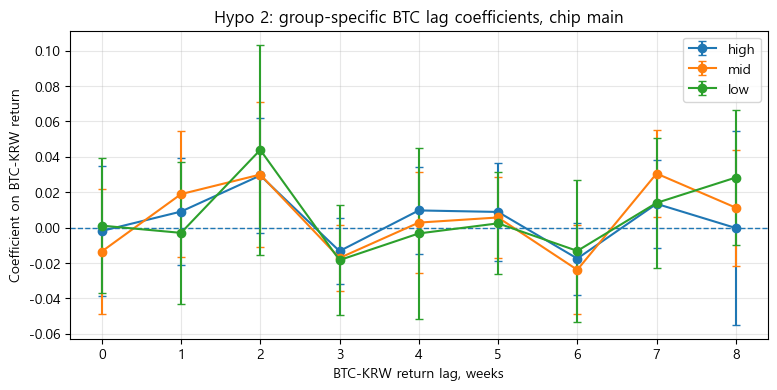

In [12]:
# 6. Group-specific distributed lag coefficients

def lin_est(model, terms, label, group, lag, block):
    names = list(model.params.index)
    R = np.zeros((1, len(names)))
    for term in terms:
        R[0, names.index(term)] += 1.0
    test = model.t_test(R)
    return {
        "block": block,
        "group": group,
        "lag_week": lag,
        "term_label": label,
        "coef": float(np.asarray(test.effect).ravel()[0]),
        "se": float(np.asarray(test.sd).ravel()[0]),
        "p_value": float(np.asarray(test.pvalue).ravel()[0]),
    }


def lag_coef_table(model, block):
    rows = []
    for k in range(L + 1):
        base = f"btc_krw_ret_l{k}"
        rows.append(lin_est(model, [base], f"low_l{k}", "low", k, block))
        rows.append(lin_est(model, [base, f"mid_btc_l{k}"], f"mid_l{k}", "mid", k, block))
        rows.append(lin_est(model, [base, f"high_btc_l{k}"], f"high_l{k}", "high", k, block))
    return pd.DataFrame(rows)

chip_lag_coef = lag_coef_table(chip_mod, "chip_main")
vram_lag_coef = lag_coef_table(vram_mod, "vram_proxy")

print("chip group-specific BTC lag coefficients")
display(chip_lag_coef.round(5))
chip_lag_coef.to_csv(H2_DIR / "chip_lag.csv", index=False)
vram_lag_coef.to_csv(H2_DIR / "vram_lag.csv", index=False)

plt.figure(figsize=(9, 4))
for group in GROUPS:
    sub = chip_lag_coef[chip_lag_coef["group"] == group].sort_values("lag_week")
    plt.errorbar(
        sub["lag_week"],
        sub["coef"],
        yerr=1.96 * sub["se"],
        marker="o",
        capsize=3,
        label=group,
    )
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Hypo 2: group-specific BTC lag coefficients, chip main")
plt.xlabel("BTC-KRW return lag, weeks")
plt.ylabel("Coefficient on BTC-KRW return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: 성능군별 lag coefficient profile</mark></b></span><br><br>
<b>[chip 기준 lag profile]</b><br>
chip 기준에서 10% 수준으로 보이는 개별 lag는 high lag 2: coef 0.0295, p 0.074; mid lag 3: coef -0.0172, p 0.067; mid lag 6: coef -0.0239, p 0.063; high lag 6: coef -0.0175, p 0.092; mid lag 7: coef 0.0306, p 0.015이다. 그러나 유의하게 보이는 lag가 high에 일관되게 몰려 있지 않고, mid와 high에서 부호가 섞인다. 따라서 그래프상 특정 시차의 점을 가설 지지로 과대해석하면 안 된다.<br><br>
<b>[VRAM 기준 lag profile]</b><br>
VRAM 기준에서 10% 수준으로 보이는 개별 lag는 high lag 2: coef 0.0373, p 0.060; mid lag 3: coef -0.0213, p 0.056; high lag 3: coef -0.0190, p 0.052; mid lag 6: coef -0.0278, p 0.050; high lag 6: coef -0.0204, p 0.064; mid lag 7: coef 0.0384, p 0.003; low lag 8: coef 0.0154, p 0.025이다. 특히 mid lag 7이 강하게 나타나지만, 이는 VRAM proxy에서만 강하고 chip 기준 본분석 및 제품 FE에서는 재현되지 않는다.<br><br>
<b>[해석]</b><br>
그림은 lag별 반응 형태를 설명하는 데 유용하지만, 최종 결론은 개별 점이 아니라 공동 유의성·누적효과·강건성 분석의 일관성으로 판단해야 한다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>7. 다중공선성 점검: BTC, 환율, NVDA</mark></b></span><br><br>

<b>[왜 VIF를 확인하는가]</b><br>
BTC와 NVDA는 일부 기간에 함께 상승하거나 하락할 수 있다. 이 경우 회귀계수 자체가 틀렸다는 뜻은 아니지만, 표준오차가 커져서 유의성이 약해질 수 있다. 따라서 주요 시장변수의 VIF를 확인한다.<br><br>

<b>[해석 기준]</b><br>
• VIF가 5 미만이면 대체로 큰 문제는 아니라고 본다.<br>
• VIF가 10 이상이면 다중공선성 가능성을 강하게 의심한다.<br>
• BTC lag를 0~8주까지 많이 넣는 모델에서는 lag끼리의 상관 때문에 VIF가 커질 수 있으므로, 이 경우 개별 lag p-value보다 공동 유의성 검정과 누적 효과를 함께 해석한다.
</div>

In [13]:
# 7. VIF: 주요 시장변수 및 BTC lag 다중공선성 점검

def get_vif(df, cols, block):
    X = df[cols].dropna().astype(float).copy()
    X = sm.add_constant(X)
    rows = []
    for i, col in enumerate(X.columns):
        rows.append({
            "block": block,
            "variable": col,
            "VIF": variance_inflation_factor(X.values, i),
        })
    return pd.DataFrame(rows)

vif_core = get_vif(chip_reg, ["btc_krw_ret_l0", "fx_ret", "nvda_ret", "gpu_ret_l1"], "chip_core")
vif_full = get_vif(chip_reg, btc_lags + ["fx_ret", "nvda_ret", "gpu_ret_l1"], "chip_lag_full")

print("VIF core")
display(vif_core.round(3))
print("VIF with BTC lags")
display(vif_full.round(3))

vif_core.to_csv(H2_DIR / "vif_core.csv", index=False)
vif_full.to_csv(H2_DIR / "vif_full.csv", index=False)

VIF core


,block,variable,VIF
0,chip_core,const,1.065
1,chip_core,btc_krw_ret_l0,1.225
2,chip_core,fx_ret,1.037
3,chip_core,nvda_ret,1.099
4,chip_core,gpu_ret_l1,1.156


VIF with BTC lags


,block,variable,VIF
0,chip_lag_full,const,1.077
1,chip_lag_full,btc_krw_ret_l0,1.407
2,chip_lag_full,btc_krw_ret_l1,1.395
3,chip_lag_full,btc_krw_ret_l2,1.437
4,chip_lag_full,btc_krw_ret_l3,1.386
5,chip_lag_full,btc_krw_ret_l4,1.420
6,chip_lag_full,btc_krw_ret_l5,1.273
7,chip_lag_full,btc_krw_ret_l6,1.260
8,chip_lag_full,btc_krw_ret_l7,1.276
9,chip_lag_full,btc_krw_ret_l8,1.215


<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: VIF 다중공선성 점검</mark></b></span><br><br>
<b>[core VIF]</b><br>
core 변수 VIF는 BTC lag0 1.225, FX 1.037, NVDA 1.099, GPU lag1 1.156로 모두 매우 낮다.<br><br>
<b>[full lag VIF]</b><br>
BTC lag 0~8을 모두 포함한 full VIF의 최댓값도 1.437 수준이다. 일반적으로 우려 기준인 5 또는 10에 훨씬 못 미치므로, 본분석에서 유의하지 않은 결과가 다중공선성 때문에 가려졌다고 보기는 어렵다.<br><br>
<b>[결론]</b><br>
따라서 Hypo 2의 비유의성은 'BTC, NVDA, FX가 너무 같이 움직여서 표준오차가 크게 부풀었다'기보다는 실제로 성능군별 BTC 민감도 차이가 약했기 때문일 가능성이 더 크다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>8. VRAM proxy 강건성 분석</mark></b></span><br><br>

<b>[왜 VRAM proxy를 따로 보는가]</b><br>
칩셋 기준이 본분석이지만, 발표 슬라이드에서는 8GB/16GB/24GB처럼 VRAM이 직관적인 성능 proxy로 제시되어 있다. 따라서 VRAM 기준 high/mid/low에서도 같은 방향의 결과가 나오는지 확인한다.<br><br>

<b>[주의]</b><br>
VRAM은 성능 그 자체가 아니다. 12GB 이상이어도 RTX 3060 12GB처럼 실제 칩셋 성능은 mid급일 수 있고, 8GB여도 RTX 3070 Ti처럼 성능이 high에 가까운 제품이 있을 수 있다. 따라서 앞의 cross-tab에서 chip_perf_group과 h2_perf_group이 얼마나 일치하는지 확인하고, VRAM 결과는 본결론을 보조하는 강건성 분석으로만 사용한다.<br><br>

<b>[실행 후 해석]</b><br>
chip 기준과 VRAM 기준이 모두 high 그룹에서 더 큰 BTC 민감도를 보이면 Hypo 2의 설득력이 올라간다. 반대로 둘이 다르면 “성능을 VRAM만으로 대리하기 어렵다”는 한계로 정리한다.
</div>

VRAM proxy model summary
                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     5.111
Date:                Sun, 03 May 2026   Prob (F-statistic):           8.77e-11
Time:                        19:08:10   Log-Likelihood:                 1073.7
No. Observations:                 291   AIC:                            -2073.
Df Residuals:                     254   BIC:                            -1937.
Df Model:                          36                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              

,block,test,F_stat,p_value,df_num,df_denom
3,vram_proxy,high_vs_low_BTC_lags_joint_zero,0.97570,0.46504,9.0,96.0
4,vram_proxy,mid_vs_low_BTC_lags_joint_zero,2.48160,0.01360,9.0,96.0
5,vram_proxy,all_group_BTC_interactions_joint_zero,1.65144,0.06249,18.0,96.0


VRAM proxy cumulative effects


,block,test,estimate,se,t,p_value
5,vram_proxy,low_cumulative_BTC_effect,-0.00093,0.01994,-0.04668,0.96277
6,vram_proxy,high_cumulative_BTC_effect,0.04795,0.03453,1.38875,0.16491
7,vram_proxy,mid_cumulative_BTC_effect,0.04897,0.02907,1.68469,0.09205
8,vram_proxy,high_minus_low_cumulative_BTC_effect,0.04888,0.04099,1.19242,0.23310
9,vram_proxy,mid_minus_low_cumulative_BTC_effect,0.04990,0.03464,1.44069,0.14967


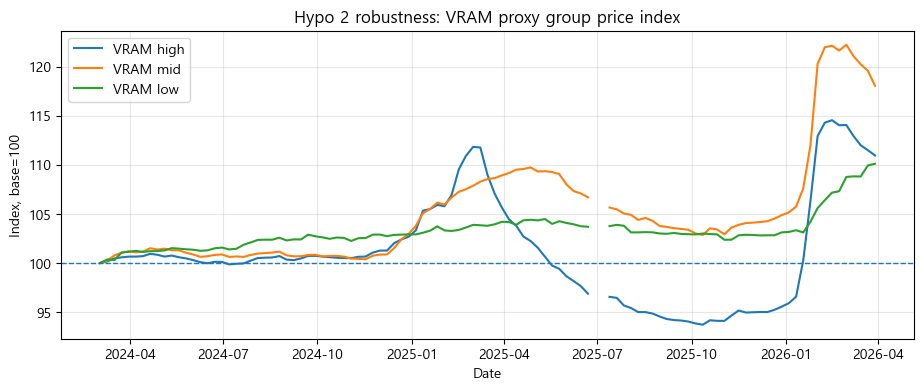

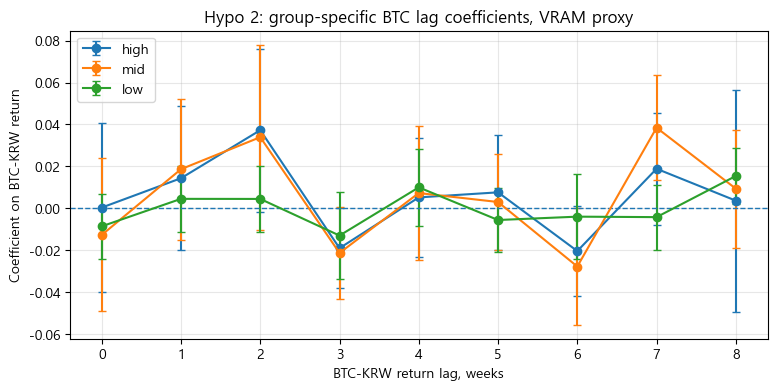

In [14]:
# 8. VRAM proxy robustness result display

print("VRAM proxy model summary")
print(vram_mod.summary())

print("VRAM proxy joint tests")
display(main_joint[main_joint["block"] == "vram_proxy"].round(5))

print("VRAM proxy cumulative effects")
display(main_cum[main_cum["block"] == "vram_proxy"].round(5))

plt.figure(figsize=(11, 4))
for g in vram_cols:
    plt.plot(idx_vram_w.index, idx_vram_w[g], label=f"VRAM {g}")
plt.axhline(100, linestyle="--", linewidth=1)
plt.title("Hypo 2 robustness: VRAM proxy group price index")
plt.xlabel("Date")
plt.ylabel("Index, base=100")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
for group in GROUPS:
    sub = vram_lag_coef[vram_lag_coef["group"] == group].sort_values("lag_week")
    plt.errorbar(
        sub["lag_week"],
        sub["coef"],
        yerr=1.96 * sub["se"],
        marker="o",
        capsize=3,
        label=group,
    )
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Hypo 2: group-specific BTC lag coefficients, VRAM proxy")
plt.xlabel("BTC-KRW return lag, weeks")
plt.ylabel("Coefficient on BTC-KRW return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: VRAM proxy 강건성 분석</mark></b></span><br><br>
<b>[결과 요약]</b><br>
VRAM 기준에서는 mid-vs-low 공동검정이 p-value 0.0136로 유의하고, 전체 상호작용도 p-value 0.062로 10% 수준에 가깝다. 그러나 high-vs-low는 p-value 0.465로 유의하지 않다.<br><br>
<b>[누적효과와 방향]</b><br>
VRAM high-minus-low 누적효과는 0.0489, p-value 0.233이고, mid-minus-low는 0.0499, p-value 0.150이다. 방향은 양수지만 통계적으로 확실하지 않다.<br><br>
<b>[왜 보조로만 보는가]</b><br>
VRAM proxy의 불일치율이 24.9%이고, chip 기준 mid 제품의 상당수가 VRAM high로 분류된다. 따라서 VRAM 결과는 '일부 메모리 용량 구간에서 BTC 민감도 신호가 있을 수 있다'는 보조 결과이지, '고성능 GPU일수록 더 민감하다'는 본결론으로 쓰기 어렵다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>9. 제품 단위 패널 강건성: product fixed effect</mark></b></span><br><br>

<b>[왜 제품 단위 패널을 추가하는가]</b><br>
성능군별 지수는 high/mid/low 세 개의 주간 시계열이므로 표본 수가 제한적이다. 이미 저장된 <b>panel_gpu.csv</b>에는 제품-주 단위 로그수익률이 있으므로, 제품 단위에서 같은 결론이 유지되는지 확인한다.<br><br>

<b>[product fixed effect 의미]</b><br>
제품마다 평균 가격 수준, 브랜드, 라인업, 기본 할인 패턴이 다를 수 있다. 이를 제거하기 위해 각 제품별 평균을 빼는 within transformation을 사용한다. 이렇게 하면 제품 고유 특성은 제거되고, 시간에 따라 변하는 BTC/FX/NVDA와 성능군 상호작용만 남는다.<br><br>

<b>[주의]</b><br>
제품 단위 패널은 같은 주차의 시장변수를 모든 제품이 공유하므로, 표준오차는 date 기준 cluster-robust로 계산한다. 제품 고정효과는 제품 고유 특성은 제거하지만, 제품이 새로 등장하는 시점 자체의 충격을 완벽히 제거하지는 못한다. 따라서 이 분석은 본분석을 대체하는 것이 아니라 <b>강건성 확인</b>이다.
</div>

In [15]:
# 9. Product-level panel robustness with product fixed effects

panel = panel_gpu[panel_gpu["chip_perf_group"].isin(GROUPS)].copy()
panel = panel.merge(mkt.reset_index().rename(columns={mkt.index.name or "index": "date"}), on="date", how="inner")
panel = panel.sort_values(["row_id", "date"]).copy()

panel["is_high"] = (panel["chip_perf_group"] == "high").astype(int)
panel["is_mid"] = (panel["chip_perf_group"] == "mid").astype(int)

for col in btc_lags:
    lag = col.replace("btc_krw_ret_l", "")
    panel[f"high_btc_l{lag}"] = panel["is_high"] * panel[col]
    panel[f"mid_btc_l{lag}"] = panel["is_mid"] * panel[col]

panel["high_nvda_ret"] = panel["is_high"] * panel["nvda_ret"]
panel["mid_nvda_ret"] = panel["is_mid"] * panel["nvda_ret"]
panel["high_fx_ret"] = panel["is_high"] * panel["fx_ret"]
panel["mid_fx_ret"] = panel["is_mid"] * panel["fx_ret"]

prod_x = (
    btc_lags
    + hi_btc
    + mid_btc
    + ["fx_ret", "nvda_ret", "high_fx_ret", "mid_fx_ret", "high_nvda_ret", "mid_nvda_ret"]
)
prod_reg = panel[["row_id", "date", "gpu_log_return", "chip_perf_group"] + prod_x].dropna().copy()

# within transformation: 제품별 평균 제거
within_cols = ["gpu_log_return"] + prod_x
prod_dm = prod_reg[within_cols] - prod_reg.groupby("row_id")[within_cols].transform("mean")

y_fe = prod_dm["gpu_log_return"].astype(float)
X_fe = prod_dm[prod_x].astype(float)

prod_mod = sm.OLS(y_fe, X_fe).fit(
    cov_type="cluster",
    cov_kwds={"groups": prod_reg["date"]}
)

prod_coef = pd.DataFrame({
    "term": prod_mod.params.index,
    "coef": prod_mod.params.values,
    "se": prod_mod.bse.values,
    "t": prod_mod.tvalues.values,
    "p_value": prod_mod.pvalues.values,
})

prod_sample = pd.DataFrame([{
    "obs_n": len(prod_reg),
    "product_n": prod_reg["row_id"].nunique(),
    "week_n": prod_reg["date"].nunique(),
}])

print(prod_mod.summary())
print("product FE panel sample")
display(prod_sample)
print("product FE coefficient table")
display(prod_coef.round(5))

# 제품 FE 모델에서도 high/mid 상호작용 공동 유의성 확인
prod_joint = pd.DataFrame([
    joint_test(prod_mod, hi_btc, "product_FE_high_vs_low_BTC_lags_joint_zero", "product_FE"),
    joint_test(prod_mod, mid_btc, "product_FE_mid_vs_low_BTC_lags_joint_zero", "product_FE"),
    joint_test(prod_mod, hi_btc + mid_btc, "product_FE_all_group_BTC_interactions_joint_zero", "product_FE"),
])

prod_cum = pd.DataFrame([
    cum_test(prod_mod, btc_lags, "product_FE_low_cumulative_BTC_effect", "product_FE"),
    cum_test(prod_mod, btc_lags + hi_btc, "product_FE_high_cumulative_BTC_effect", "product_FE"),
    cum_test(prod_mod, btc_lags + mid_btc, "product_FE_mid_cumulative_BTC_effect", "product_FE"),
    cum_test(prod_mod, hi_btc, "product_FE_high_minus_low_cumulative_BTC_effect", "product_FE"),
    cum_test(prod_mod, mid_btc, "product_FE_mid_minus_low_cumulative_BTC_effect", "product_FE"),
])

print("product FE joint tests")
display(prod_joint.round(5))
print("product FE cumulative effects")
display(prod_cum.round(5))

prod_sample.to_csv(H2_DIR / "prod_fe_sample.csv", index=False)
prod_coef.to_csv(H2_DIR / "prod_fe_coef.csv", index=False)
prod_joint.to_csv(H2_DIR / "prod_fe_joint.csv", index=False)
prod_cum.to_csv(H2_DIR / "prod_fe_cum.csv", index=False)

                                 OLS Regression Results                                
Dep. Variable:         gpu_log_return   R-squared (uncentered):                   0.005
Model:                            OLS   Adj. R-squared (uncentered):              0.004
Method:                 Least Squares   F-statistic:                              2.239
Date:                Sun, 03 May 2026   Prob (F-statistic):                     0.00127
Time:                        19:08:25   Log-Likelihood:                          88058.
No. Observations:               66091   AIC:                                 -1.761e+05
Df Residuals:                   66058   BIC:                                 -1.758e+05
Df Model:                          33                                                  
Covariance Type:              cluster                                                  
                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

,obs_n,product_n,week_n
0,66091,1840,97


product FE coefficient table


,term,coef,se,t,p_value
0,btc_krw_ret_l0,-0.05344,0.05184,-1.03098,0.30255
1,btc_krw_ret_l1,0.02321,0.03950,0.58762,0.55679
2,btc_krw_ret_l2,0.03776,0.06119,0.61702,0.53722
3,btc_krw_ret_l3,0.02779,0.03179,0.87425,0.38198
4,btc_krw_ret_l4,0.01785,0.03390,0.52640,0.59861
5,btc_krw_ret_l5,0.00766,0.02648,0.28927,0.77237
6,btc_krw_ret_l6,-0.01247,0.03609,-0.34547,0.72974
7,btc_krw_ret_l7,0.02790,0.03870,0.72089,0.47098
8,btc_krw_ret_l8,0.04532,0.03568,1.27016,0.20403
9,high_btc_l0,-0.00628,0.04510,-0.13921,0.88929


product FE joint tests


,block,test,F_stat,p_value,df_num,df_denom
0,product_FE,product_FE_high_vs_low_BTC_lags_joint_zero,0.37341,0.94518,9.0,96.0
1,product_FE,product_FE_mid_vs_low_BTC_lags_joint_zero,0.86069,0.56291,9.0,96.0
2,product_FE,product_FE_all_group_BTC_interactions_joint_zero,1.05128,0.41263,18.0,96.0


product FE cumulative effects


,block,test,estimate,se,t,p_value
0,product_FE,product_FE_low_cumulative_BTC_effect,0.12157,0.10246,1.18655,0.23540
1,product_FE,product_FE_high_cumulative_BTC_effect,0.02300,0.04240,0.54250,0.58747
2,product_FE,product_FE_mid_cumulative_BTC_effect,-0.01514,0.04378,-0.34572,0.72955
3,product_FE,product_FE_high_minus_low_cumulative_BTC_effect,-0.09857,0.10082,-0.97769,0.32823
4,product_FE,product_FE_mid_minus_low_cumulative_BTC_effect,-0.13671,0.08958,-1.52621,0.12696


<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: Product fixed effect robustness</mark></b></span><br><br>
<b>[표본과 목적]</b><br>
제품 단위 FE 분석은 66,091개 제품-주 관측치와 1,840개 제품을 사용했다. 제품별 평균 차이를 제거했기 때문에 브랜드·모델 고유 가격 수준 같은 시간불변 특성은 상당 부분 통제된다.<br><br>
<b>[공동검정 결과]</b><br>
product FE에서 high-vs-low 공동검정 p-value는 0.945, mid-vs-low는 0.563, 전체 상호작용항은 0.413이다. 제품 단위 대규모 표본에서도 성능군별 BTC 민감도 차이는 확인되지 않는다.<br><br>
<b>[누적효과 결과]</b><br>
product FE의 high-minus-low 누적효과는 -0.0986, p-value 0.328로 유의하지 않고 방향도 음수이다. 이는 그룹지수 본분석의 결론과 일치한다.<br><br>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>10. Hypo 2 최종 요약 테이블</mark></b></span><br><br>

<b>[무엇을 최종적으로 볼 것인가]</b><br>
Hypo 2의 결론은 아래 순서로 판단한다.<br><br>

<b>1순위: chip_main interaction regression</b><br>
• high_vs_low_BTC_lags_joint_zero의 p-value<br>
• high_minus_low_cumulative_BTC_effect의 부호와 p-value<br><br>

<b>2순위: 보완 강건성 분석</b><br>
• <b>composition-control robustness</b>: 제품 진입/활성 제품 수/bridge gap을 통제해도 high-low 결과가 유지되는지 확인<br>
• <b>lag-window robustness</b>: 0~8주 lag를 구간으로 묶어 자유도·공선성 문제를 줄여도 방향이 유지되는지 확인<br><br>

<b>3순위: VRAM proxy robustness</b><br>
• VRAM 기준에서도 high 그룹이 더 큰 BTC 민감도를 보이는지 확인하되, VRAM은 성능 proxy의 한계가 있으므로 chip 기준과 다를 경우 본결론보다 낮은 가중치로 해석한다.<br><br>

<b>4순위: product FE robustness</b><br>
• 제품 고유 특성을 제거해도 high-low 차이가 유지되는지 확인한다.<br><br>

<b>[결론 문장 작성 기준]</b><br>
• chip main, composition-control, lag-window, product FE에서 high-low 누적 차이가 대체로 양수이고 유의하면: <b>Hypo 2는 지지된다</b>.<br>
• 방향은 양수이나 p-value가 약하면: <b>방향성은 있으나 통계적으로 강한 증거는 부족하다</b>.<br>
• 결과가 chip과 VRAM 또는 제품 패널에서 엇갈리면: <b>성능군 정의, 신제품/표본구성 변화, lag 설정에 민감하므로 제한적으로 해석한다</b>.<br>
• 신제품 출시 더미를 정확히 넣지 못한 점은 본분석의 한계로 인정하되, 본 노트북에서는 데이터 내부의 제품구성 proxy로 해당 위험을 보조 점검했다.
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 저장 파일명 정리</mark></b></span><br><br>
<b>[변경 이유]</b><br>
기존 output 파일명은 설명적이지만 너무 길어 후속 분석에서 불편하므로, Hypo 2 output은 짧고 직관적인 이름으로 저장하도록 정리하였다.<br><br>
<b>[핵심 저장 파일]</b><br>
• <b>sample.csv</b>: chip/VRAM 회귀 표본 크기<br>
• <b>chip_sample.csv</b>, <b>vram_sample.csv</b>: 성능군별 제품 수와 VRAM 분포<br>
• <b>anova.csv</b>: ANOVA/Welch 탐색 검정<br>
• <b>chip_coef.csv</b>, <b>joint.csv</b>, <b>cum.csv</b>: chip 본분석 상호작용 회귀 결과<br>
• <b>comp_coef.csv</b>, <b>comp_joint.csv</b>, <b>comp_cum.csv</b>: 제품구성 통제 강건성<br>
• <b>win_coef.csv</b>, <b>win_joint.csv</b>, <b>win_cum.csv</b>: lag-window 강건성<br>
• <b>vram_coef.csv</b>, <b>vram_lag.csv</b>: VRAM proxy 강건성<br>
• <b>prod_fe_coef.csv</b>, <b>prod_fe_joint.csv</b>, <b>prod_fe_cum.csv</b>: 제품 고정효과 강건성<br>
• <b>summary.csv</b>: Hypo 2 최종 요약표<br><br>
<b>[주의]</b><br>
짧은 파일명은 새 노트북을 재실행하면 <code>outputs/hypo2/</code>에 저장된다. 기존 긴 이름의 CSV는 과거 실행 결과 백업으로 남겨두어도 무방하다.
</div>

In [16]:
# 10. H2 final summary

sum_rows = []

# ANOVA/Welch 요약
for _, row in anova_results.iterrows():
    if row["test"] in ["One_way_ANOVA", "Welch_ANOVA"]:
        sum_rows.append({
            "block": row["block"],
            "metric": row["test"],
            "estimate": row["stat"],
            "p_value": row["p_value"],
            "interpretation_target": "group mean return difference, exploratory only",
        })

joint_list = [
    main_joint,
    comp_joint,
    win_joint,
    prod_joint,
]

cum_list = [
    main_cum,
    comp_cum,
    win_cum,
    prod_cum,
]

# Main/robust interaction 요약
for table in joint_list:
    for _, row in table.iterrows():
        sum_rows.append({
            "block": row["block"],
            "metric": row["test"],
            "estimate": row["F_stat"],
            "p_value": row["p_value"],
            "interpretation_target": "joint significance of BTC sensitivity difference",
        })

for table in cum_list:
    for _, row in table.iterrows():
        sum_rows.append({
            "block": row["block"],
            "metric": row["test"],
            "estimate": row["estimate"],
            "p_value": row["p_value"],
            "interpretation_target": "cumulative BTC response over lag structure",
        })

h2_sum = pd.DataFrame(sum_rows)

print("Hypo 2 summary")
display(h2_sum.round(5))
h2_sum.to_csv(H2_DIR / "summary.csv", index=False)

print("saved files to:", H2_DIR)
print("main files:")
for name in [
    "vram_chip_n.csv",
    "vram_mismatch.csv",
    "comp_diag.csv",
    "comp_sum.csv",
    "anova.csv",
    "chip_coef.csv",
    "joint.csv",
    "cum.csv",
    "chip_lag.csv",
    "vif_core.csv",
    "vif_full.csv",
    "comp_coef.csv",
    "comp_joint.csv",
    "comp_cum.csv",
    "win_coef.csv",
    "win_joint.csv",
    "win_cum.csv",
    "prod_fe_coef.csv",
    "prod_fe_joint.csv",
    "prod_fe_cum.csv",
    "summary.csv",
]:
    print("-", H2_DIR / name)

Hypo 2 summary


,block,metric,estimate,p_value,interpretation_target
0,chip_main,One_way_ANOVA,0.48481,0.61627,"group mean return difference, exploratory only"
1,chip_main,Welch_ANOVA,0.47715,0.62123,"group mean return difference, exploratory only"
2,vram_proxy,One_way_ANOVA,0.25420,0.77569,"group mean return difference, exploratory only"
3,vram_proxy,Welch_ANOVA,0.33437,0.71628,"group mean return difference, exploratory only"
4,chip_main,high_vs_low_BTC_lags_joint_zero,0.45585,0.90043,joint significance of BTC sensitivity difference
5,chip_main,mid_vs_low_BTC_lags_joint_zero,1.01484,0.43381,joint significance of BTC sensitivity difference
6,chip_main,all_group_BTC_interactions_joint_zero,0.88121,0.60176,joint significance of BTC sensitivity difference
7,vram_proxy,high_vs_low_BTC_lags_joint_zero,0.97570,0.46504,joint significance of BTC sensitivity difference
8,vram_proxy,mid_vs_low_BTC_lags_joint_zero,2.48160,0.01360,joint significance of BTC sensitivity difference
9,vram_proxy,all_group_BTC_interactions_joint_zero,1.65144,0.06249,joint significance of BTC sensitivity difference


saved files to: outputs\hypo2
main files:
- outputs\hypo2\vram_chip_n.csv
- outputs\hypo2\vram_mismatch.csv
- outputs\hypo2\comp_diag.csv
- outputs\hypo2\comp_sum.csv
- outputs\hypo2\anova.csv
- outputs\hypo2\chip_coef.csv
- outputs\hypo2\joint.csv
- outputs\hypo2\cum.csv
- outputs\hypo2\chip_lag.csv
- outputs\hypo2\vif_core.csv
- outputs\hypo2\vif_full.csv
- outputs\hypo2\comp_coef.csv
- outputs\hypo2\comp_joint.csv
- outputs\hypo2\comp_cum.csv
- outputs\hypo2\win_coef.csv
- outputs\hypo2\win_joint.csv
- outputs\hypo2\win_cum.csv
- outputs\hypo2\prod_fe_coef.csv
- outputs\hypo2\prod_fe_joint.csv
- outputs\hypo2\prod_fe_cum.csv
- outputs\hypo2\summary.csv


<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>📌 실행결과 해석: Hypo 2 최종 판단</mark></b></span><br><br>
<b>[최종 결론]</b><br>
본 실행결과 기준으로 Hypo 2, 즉 '고성능 GPU일수록 BTC 가격 변동에 더 민감하다'는 주장은 강하게 지지되지 않는다. chip 기준 본분석, composition-control, lag-window, product FE가 모두 high-vs-low 차이를 유의하게 보여주지 못했고, high-minus-low 누적효과도 대체로 0에 가깝거나 음수이다.<br><br>
<b>[VRAM 결과의 위치]</b><br>
VRAM proxy에서는 mid-vs-low 공동검정에서 일부 신호가 있었지만, high-vs-low가 유의하지 않고 VRAM-성능군 불일치율도 높다. 따라서 VRAM 결과는 본결론을 뒤집는 근거가 아니라, 성능 proxy 정의에 따라 일부 결과가 달라질 수 있다는 한계와 보조분석으로 제시하는 것이 적절하다.<br><br>
<b>[보고서/발표 문장]</b><br>
따라서 보고서에서는 '성능군별 GPU 가격 변동률에 대해 BTC 수익률과 성능군의 상호작용을 검정했으나, 칩셋 성능 기준 본분석과 주요 강건성 분석에서 고성능 GPU의 추가 민감도는 통계적으로 확인되지 않았다. VRAM 기준 일부 신호는 있으나 proxy 불일치로 인해 보조적 결과로 해석한다'고 쓰는 것이 가장 방어력 있다.<br><br>
</div>